# 🌾 Klasifikasi Fase Pertumbuhan Padi — 3 Kelas
## Vegetative | Generative | Mature

Notebook ini mengklasifikasikan fase pertumbuhan padi menjadi **3 kelas** dengan tujuan utama
mendeteksi kesiapan panen:

| Kelas | Asal Label | Deskripsi |
|-------|-----------|-----------|
| **Vegetative** | Vegetative | Fase vegetatif, tanaman masih tumbuh |
| **Generative** | Generative + Ripening_Early | Fase generatif hingga awal pemasakan |
| **Mature** | Ripening_Mature | Fase matang, siap panen |

**Strategi eksperimen:** 7 Indeks Vegetasi × 5 Model = 35 kombinasi,  
masing-masing dievaluasi dengan 5-Fold CV + test set.


## 📦 Setup & Import

In [1]:
!pip -q install opencv-python scikit-learn pandas numpy joblib tqdm imbalanced-learn scikit-image seaborn

In [2]:
import os, glob, zipfile, warnings
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from skimage.feature import graycomatrix, graycoprops
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("Import selesai ✅")


Import selesai ✅


## 📂 Load Dataset

In [3]:
import os, pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# RESUME MODE — set FORCE_REEXTRACT = True jika dataset/fitur berubah.
# Set False jika hanya ingin lanjut dari CSV yang sudah ada di Drive.
# ─────────────────────────────────────────────────────────────────────────────
FORCE_REEXTRACT = True   # ← ganti False kalau mau resume dari CSV lama

from google.colab import drive
drive.mount('/content/drive')

CSV_DRIVE = "/content/drive/MyDrive/features_3class.csv"

RESUME = os.path.exists(CSV_DRIVE) and not FORCE_REEXTRACT

if RESUME:
    df_all = pd.read_csv(CSV_DRIVE)
    print(f"✅ RESUME MODE: fitur dimuat dari Drive ({len(df_all)} baris)")
    print("   Langsung jalankan cell dari bagian Definisi Kelas (CLASS_ORDER) ke bawah.")
    print(f"   Lewati cell: upload zip, ekstraksi gambar, dan ekstraksi fitur.")
    display(df_all.groupby(["split","label"]).size().unstack(fill_value=0))
else:
    if FORCE_REEXTRACT:
        print("🔄 FORCE REEXTRACT: mengabaikan CSV lama, jalankan ekstraksi fitur dari awal.")
    else:
        print("⏭️  FRESH RUN: features_3class.csv belum ada di Drive.")
    print("   Jalankan cell berikutnya secara normal (upload zip → ekstraksi fitur).")


Mounted at /content/drive
🔄 FORCE REEXTRACT: mengabaikan CSV lama, jalankan ekstraksi fitur dari awal.
   Jalankan cell berikutnya secara normal (upload zip → ekstraksi fitur).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import glob as _glob

# Auto-detect zip padi: cari di MyDrive root + subfolder (depth 2)
DRIVE_ROOT = '/content/drive/MyDrive'

search_patterns = [
    f'{DRIVE_ROOT}/padi*.zip',
    f'{DRIVE_ROOT}/*/padi*.zip',          # 1 level subfolder
    f'{DRIVE_ROOT}/*/*/padi*.zip',        # 2 level subfolder
]

candidates = []
for pat in search_patterns:
    candidates.extend(_glob.glob(pat))

if candidates:
    # Ambil yang nama paling baru (sort by name desc)
    ZIP_PATH  = sorted(candidates)[-1]
    DRIVE_DIR = os.path.dirname(ZIP_PATH)  # parent folder zip jadi DRIVE_DIR
    print(f'Dataset ditemukan : {ZIP_PATH}')
    print(f'DRIVE_DIR         : {DRIVE_DIR}')
    print(f'(semua file output akan disimpan ke folder ini)')
else:
    print('File zip tidak ditemukan di mana pun di Drive.')
    print('Lokasi yang dicek:')
    for pat in search_patterns:
        print(f'  - {pat}')
    print('\nFile zip yang ada di MyDrive root:')
    print(_glob.glob(f'{DRIVE_ROOT}/*.zip'))
    raise FileNotFoundError(
        'Upload padi*.zip ke Google Drive (boleh di root MyDrive atau subfolder).'
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset ditemukan: /content/drive/MyDrive/padi.v10i.folder.zip


In [5]:
import zipfile

EXTRACT_DIR = "/content/padi_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

DATA_ROOT = EXTRACT_DIR
for sp in ["train", "valid", "test"]:
    if not os.path.isdir(os.path.join(DATA_ROOT, sp)):
        raise RuntimeError(f"Folder '{sp}' tidak ditemukan.")

print("Dataset siap di:", DATA_ROOT)
print("Isi:", os.listdir(DATA_ROOT))


Dataset siap di: /content/padi_dataset
Isi: ['train', 'valid', 'test', 'README.roboflow.txt', 'README.dataset.txt']


## 🌿 Definisi Semua Indeks Vegetasi

Semua indeks dihitung per-pixel dari channel R, G, B citra.
Setiap indeks merepresentasikan "kehijauan" tanaman dengan pendekatan yang berbeda.

In [6]:
def read_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def green_mask(rgb, threshold=5, min_green=40):
    """Masking piksel vegetasi hijau."""
    R = rgb[:,:,0].astype(np.int32)
    G = rgb[:,:,1].astype(np.int32)
    B = rgb[:,:,2].astype(np.int32)
    return (G > R + threshold) & (G > B + threshold) & (G > min_green)

# ── 7 Indeks Vegetasi ──────────────────────────────────────────────────────────

def compute_VARI(rgb, eps=1e-6):
    """Visible Atmospherically Resistant Index: (G-R)/(G+R-B)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return np.clip((G - R) / (G + R - B + eps), -1.0, 1.0)

def compute_ExG(rgb):
    """Excess Green Index: (2G - R - B) / 255"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (2*G - R - B) / 255.0

def compute_ExGR(rgb):
    """Excess Green minus Excess Red: ExG - 1.4R - G"""
    r = rgb.astype(np.float32) / 255.0
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    ExG = 2*G - R - B
    ExR = 1.4*R - G
    return ExG - ExR

def compute_GLI(rgb, eps=1e-6):
    """Green Leaf Index: (2G - R - B) / (2G + R + B)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (2*G - R - B) / (2*G + R + B + eps)

def compute_MGRVI(rgb, eps=1e-6):
    """Modified Green Red Vegetation Index: (G² - R²) / (G² + R²)"""
    r = rgb.astype(np.float32)
    R, G = r[:,:,0], r[:,:,1]
    return (G**2 - R**2) / (G**2 + R**2 + eps)

def compute_RGBVI(rgb, eps=1e-6):
    """RGB Vegetation Index: (G² - B·R) / (G² + B·R)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (G**2 - B*R) / (G**2 + B*R + eps)

def compute_NGRDI(rgb, eps=1e-6):
    """Normalized Green Red Difference Index: (G - R) / (G + R)"""
    r = rgb.astype(np.float32)
    R, G = r[:,:,0], r[:,:,1]
    return (G - R) / (G + R + eps)

# Registry semua indeks vegetasi
VI_REGISTRY = {
    "VARI":  compute_VARI,
    "ExG":   compute_ExG,
    "ExGR":  compute_ExGR,
    "GLI":   compute_GLI,
    "MGRVI": compute_MGRVI,
    "RGBVI": compute_RGBVI,
    "NGRDI": compute_NGRDI,
}

print(f"Total indeks vegetasi terdaftar: {len(VI_REGISTRY)}")
for name, fn in VI_REGISTRY.items():
    print(f"  - {name:6s}: {fn.__doc__.split(':')[0].strip()}")


Total indeks vegetasi terdaftar: 7
  - VARI  : Visible Atmospherically Resistant Index
  - ExG   : Excess Green Index
  - ExGR  : Excess Green minus Excess Red
  - GLI   : Green Leaf Index
  - MGRVI : Modified Green Red Vegetation Index
  - RGBVI : RGB Vegetation Index
  - NGRDI : Normalized Green Red Difference Index


In [7]:
def compute_glcm_features(gray):
    """Ekstrak 8 fitur GLCM: contrast, correlation, energy, homogeneity (mean+std)."""
    g = gray.astype(np.uint8)
    glcm = graycomatrix(g, distances=[1,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    feats = {}
    for prop in ['contrast','correlation','energy','homogeneity']:
        vals = graycoprops(glcm, prop).flatten()
        feats[f'glcm_{prop}_mean'] = float(np.mean(vals))
        feats[f'glcm_{prop}_std']  = float(np.std(vals))
    return feats

def extract_vi_stats(vi_1d):
    """10 statistik dari array 1D indeks vegetasi."""
    v = vi_1d.flatten()
    return {
        "mean":      float(np.mean(v)),
        "std":       float(np.std(v)),
        "median":    float(np.median(v)),
        "p10":       float(np.percentile(v, 10)),
        "p25":       float(np.percentile(v, 25)),
        "p75":       float(np.percentile(v, 75)),
        "p90":       float(np.percentile(v, 90)),
        "frac_gt0":  float(np.mean(v > 0)),
        "frac_gt01": float(np.mean(v > 0.1)),
        "iqr":       float(np.percentile(v, 75) - np.percentile(v, 25)),
    }

USE_GREEN_MASK = True
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
STAT_NAMES = list(extract_vi_stats(np.array([0])).keys())
GLCM_NAMES = [f'glcm_{p}_{s}' for p in ['contrast','correlation','energy','homogeneity'] for s in ['mean','std']]

print(f"Fitur statistik VI : {len(STAT_NAMES)} fitur")
print(f"Fitur GLCM         : {len(GLCM_NAMES)} fitur")
print(f"Total per VI       : {len(STAT_NAMES) + len(GLCM_NAMES)} fitur")
print(f"Total semua VI     : {(len(STAT_NAMES) + len(GLCM_NAMES)) * len(VI_REGISTRY)} fitur")


Fitur statistik VI : 10 fitur
Fitur GLCM         : 8 fitur
Total per VI       : 18 fitur
Total semua VI     : 126 fitur


## 🏷️ Definisi Kelas

Dataset sudah dilabeli manual dengan **3 kelas** langsung:

| Kelas | Deskripsi |
|-------|-----------|
| **Vegetative** | Fase vegetatif — tanaman masih tumbuh, belum berbunga |
| **Generative** | Fase generatif — malai sudah keluar, bulir sedang berkembang |
| **Mature** | Fase matang — bulir kuning keemasan, menunduk, siap panen |


In [8]:
# Dataset sudah 3 kelas langsung — tidak perlu mapping
CLASS_ORDER = ["Vegetative", "Generative", "Mature"]

print("Kelas yang digunakan:", CLASS_ORDER)


Kelas yang digunakan: ['Vegetative', 'Generative', 'Mature']


## 🔄 Ekstraksi Fitur untuk Semua Indeks Vegetasi

Setiap gambar diekstrak fiturnya untuk semua 7 indeks vegetasi sekaligus.
Label langsung diambil dari nama folder (sudah 3 kelas).

In [9]:
rows_all = []
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split in ["train", "valid", "test"]:
    split_dir  = os.path.join(DATA_ROOT, split)
    class_names = [d for d in sorted(os.listdir(split_dir))
                   if os.path.isdir(os.path.join(split_dir, d))]
    print(f"\n{split}: {class_names}")

    for cls in class_names:
        if cls not in CLASS_ORDER:
            print(f"  ⚠️  Kelas '{cls}' tidak dikenal, dilewati.")
            continue

        cls_dir   = os.path.join(split_dir, cls)
        img_paths = []
        for ext in IMAGE_EXTS:
            img_paths.extend(glob.glob(os.path.join(cls_dir, f"*{ext}")))

        for img_path in tqdm(img_paths, desc=f"{split}/{cls}"):
            rgb = read_rgb(img_path)
            if rgb is None:
                continue

            mask      = green_mask(rgb)
            gray      = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            glcm_feat = compute_glcm_features(gray)

            row = {
                "label":          cls,
                "split":          split,
                "path":           img_path,
                "green_fraction": float(mask.mean()),  # proporsi piksel hijau
            }

            for vi_name, vi_fn in VI_REGISTRY.items():
                vi_map = vi_fn(rgb)
                vi_use = vi_map.flatten()  # seluruh gambar, bukan hanya piksel hijau
                stats  = extract_vi_stats(vi_use)
                for k, v in stats.items():
                    row[f"{vi_name}_{k}"] = v

            row.update(glcm_feat)
            rows_all.append(row)

df_all = pd.DataFrame(rows_all)
print(f"\nShape total: {df_all.shape}")



train: ['Generative', 'Mature', 'Vegetative']


train/Vegetative: 100%|██████████| 306/306 [01:35<00:00,  3.19it/s]



valid: ['Generative', 'Mature', 'Vegetative']


valid/Vegetative: 100%|██████████| 24/24 [00:07<00:00,  3.23it/s]



test: ['Generative', 'Mature', 'Vegetative']


test/Vegetative: 100%|██████████| 22/22 [00:06<00:00,  3.53it/s]


Shape total: (572, 82)


In [10]:
CSV_ALL       = "/content/features_3class.csv"
CSV_ALL_DRIVE = f'{DRIVE_DIR}/features_3class.csv' if 'DRIVE_DIR' in dir() else '/content/drive/MyDrive/features_3class.csv'

df_all.to_csv(CSV_ALL, index=False)
df_all.to_csv(CSV_ALL_DRIVE, index=False)   # backup ke Drive
print("Saved lokal :", CSV_ALL)
print("Saved Drive :", CSV_ALL_DRIVE)

print("=== Distribusi Kelas ===")
counts = df_all.groupby(["split", "label"]).size().unstack(fill_value=0)
existing_classes = [c for c in CLASS_ORDER if c in counts.columns]
counts = counts[existing_classes]
display(counts)

train_counts = counts.loc["train"]
print(f"Rasio imbalance train (max/min): {train_counts.max()/train_counts.min():.1f}x")

Saved lokal : /content/features_3class.csv
Saved Drive : /content/drive/MyDrive/features_3class.csv
=== Distribusi Kelas ===


label,Vegetative,Generative,Mature
split,,,
test,22,8,5
train,306,138,57
valid,24,8,4


Rasio imbalance train (max/min): 5.4x


## 📊 EDA: Distribusi Kelas & Visualisasi Indeks Vegetasi

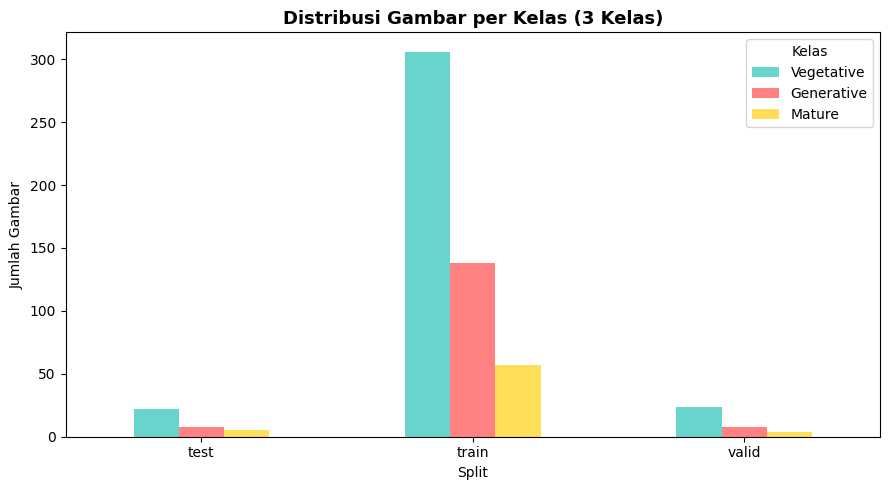

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Bar chart distribusi per split
fig, ax = plt.subplots(figsize=(9, 5))
counts.plot(kind="bar", ax=ax, color=["#4ECDC4","#FF6B6B","#FFD93D"], alpha=0.85)
ax.set_title("Distribusi Gambar per Kelas (3 Kelas)", fontsize=13, fontweight="bold")
ax.set_xlabel("Split")
ax.set_ylabel("Jumlah Gambar")
ax.legend(title="Kelas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


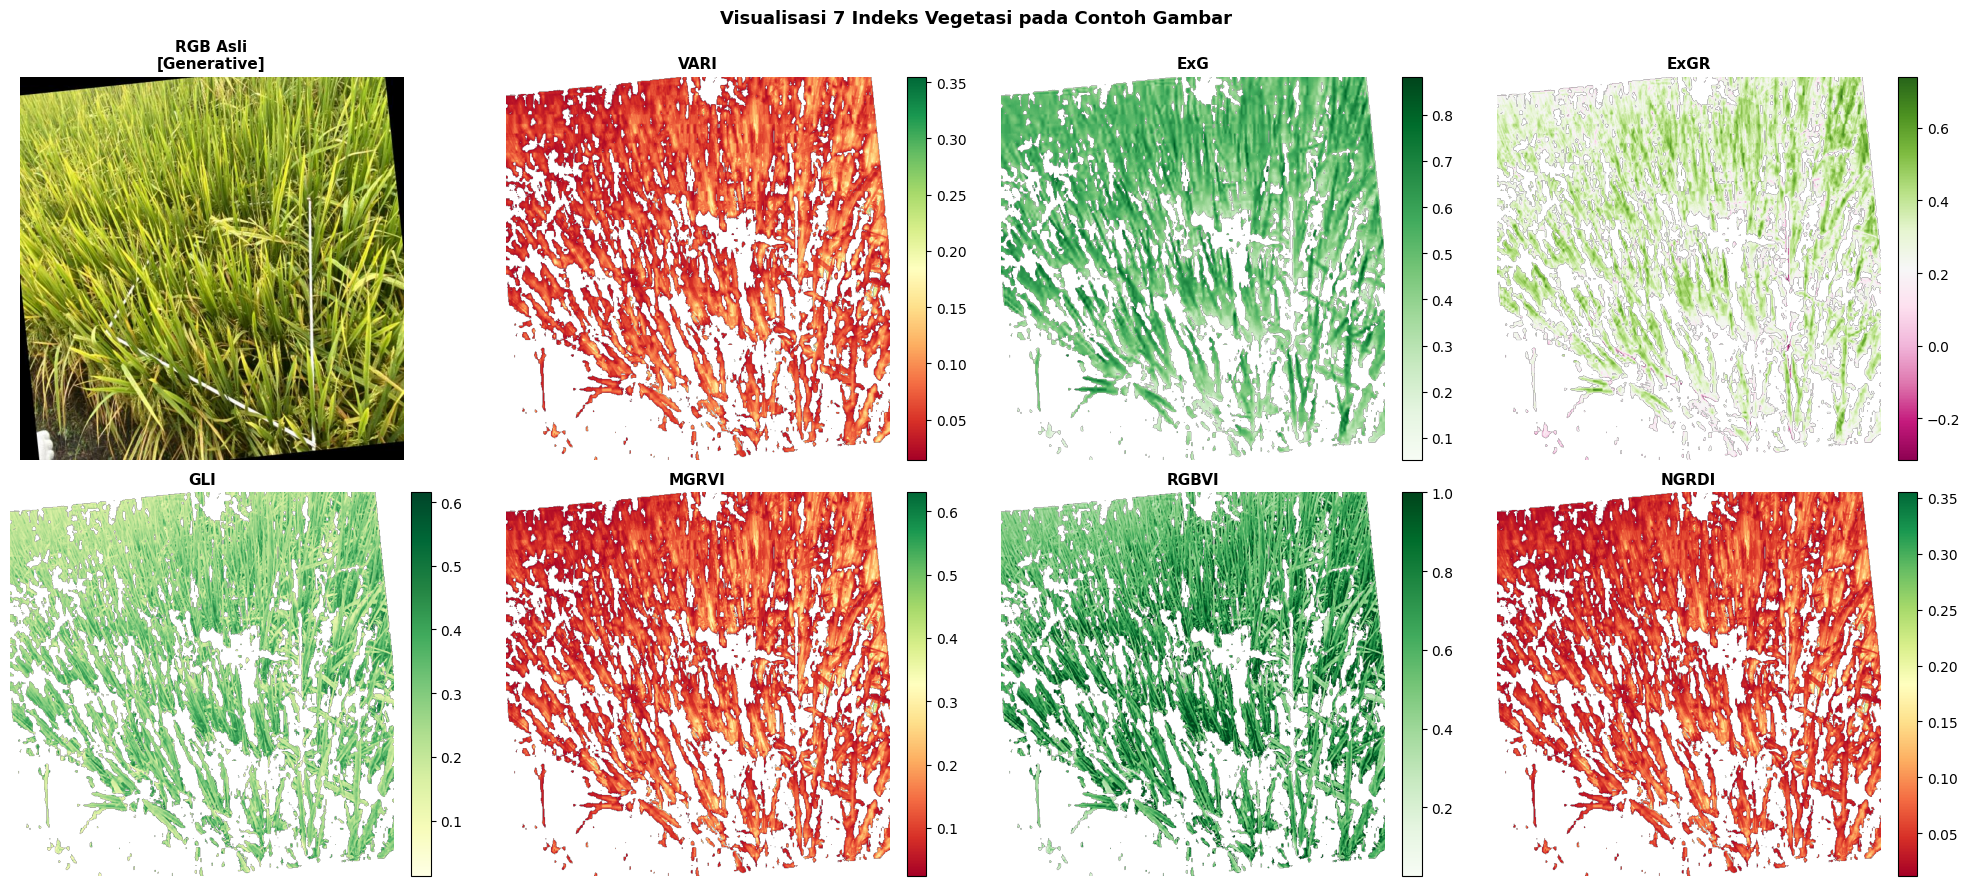

In [12]:
# Visualisasi 7 VI pada satu contoh gambar
example_path = df_all[df_all["split"]=="train"]["path"].iloc[10]
rgb  = read_rgb(example_path)
mask = green_mask(rgb)
label_ex = df_all[df_all["path"]==example_path]["label"].values[0]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

axes[0].imshow(rgb)
axes[0].set_title(f"RGB Asli\n[{label_ex}]", fontweight="bold", fontsize=11)
axes[0].axis("off")

cmaps = ["RdYlGn","Greens","PiYG","YlGn","RdYlGn","Greens","RdYlGn"]
for i, (vi_name, vi_fn) in enumerate(VI_REGISTRY.items()):
    vi_map    = vi_fn(rgb).astype(float)
    vi_masked = vi_map.copy()
    vi_masked[~mask] = np.nan
    im = axes[i+1].imshow(vi_masked, cmap=cmaps[i])
    axes[i+1].set_title(vi_name, fontweight="bold", fontsize=11)
    axes[i+1].axis("off")
    plt.colorbar(im, ax=axes[i+1], fraction=0.046, pad=0.04)

plt.suptitle("Visualisasi 7 Indeks Vegetasi pada Contoh Gambar", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Distribusi Fitur Mean per Kelas (3 Kelas)

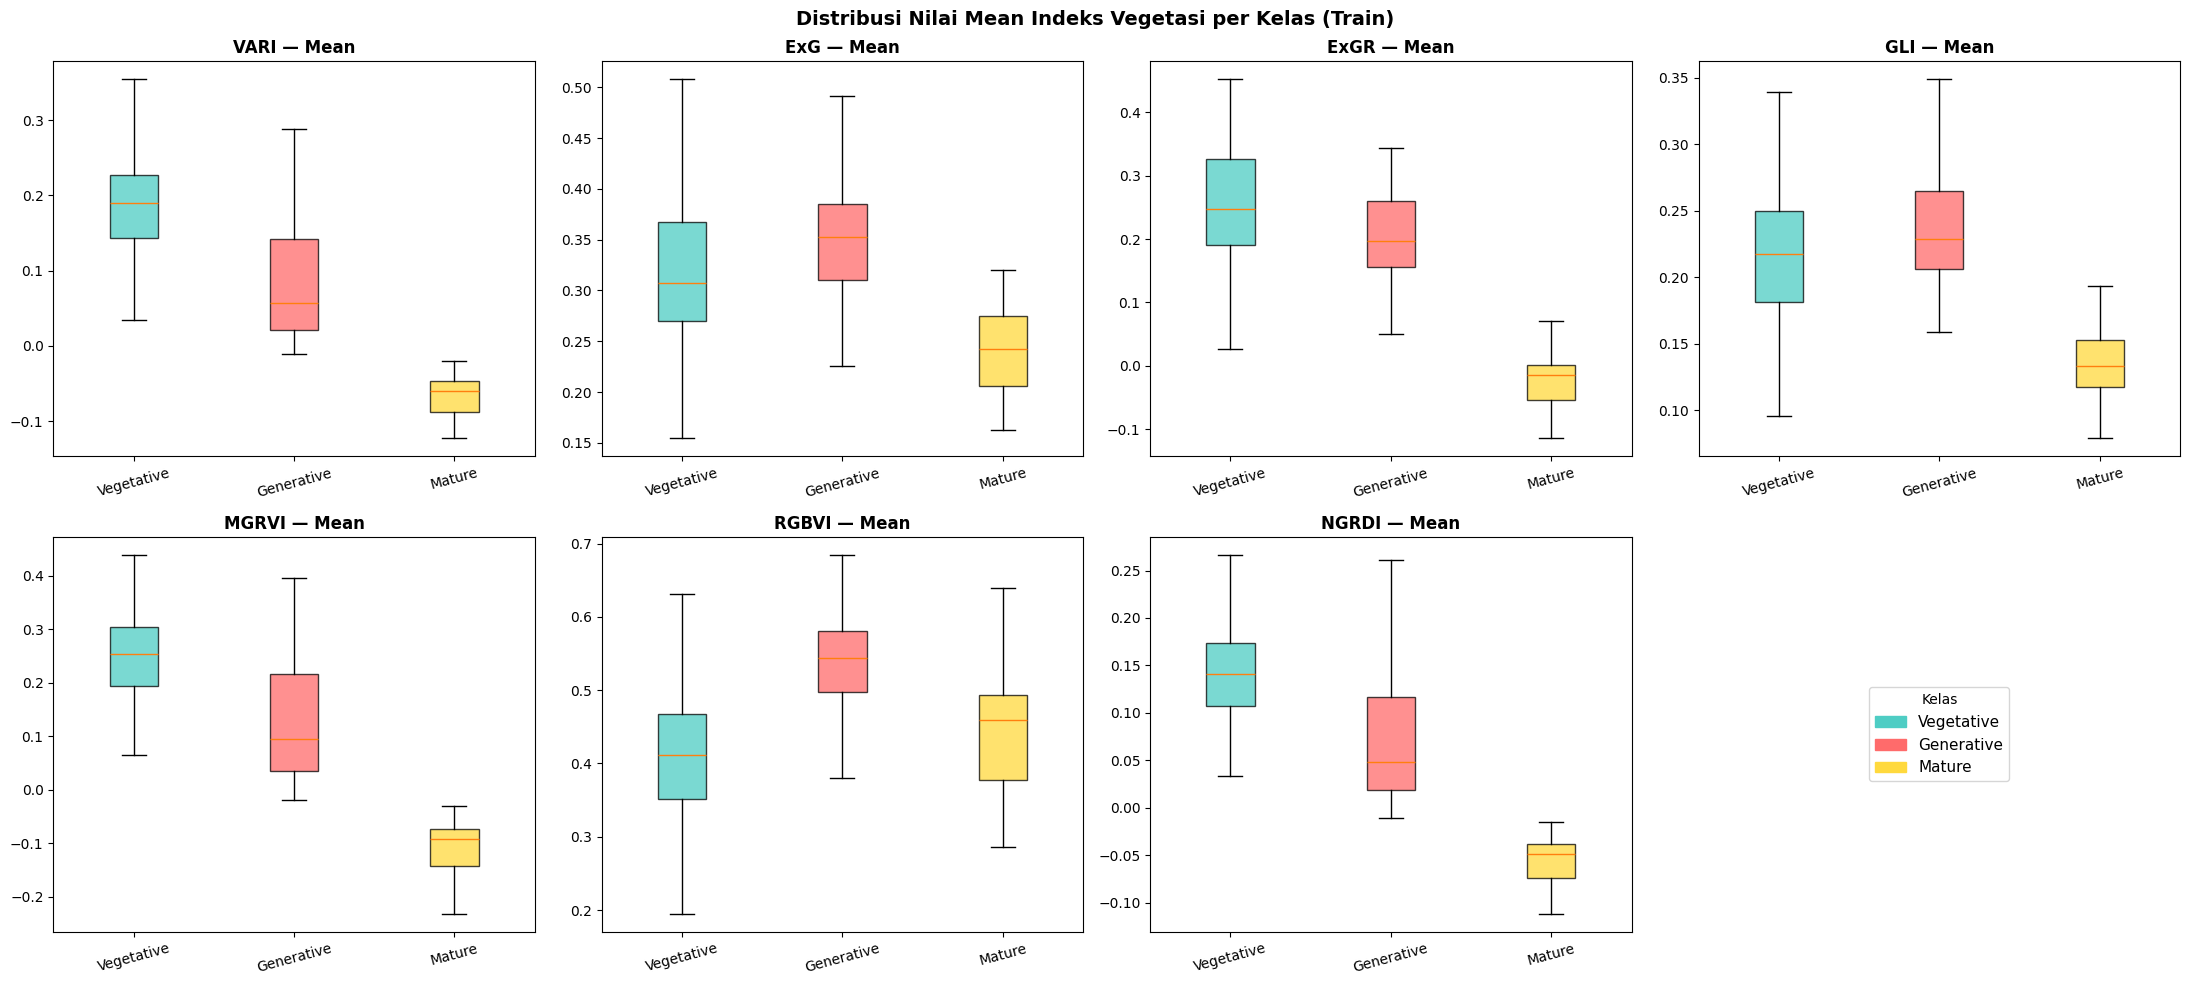

In [13]:
train_sub = df_all[df_all["split"]=="train"].copy()
vi_names  = list(VI_REGISTRY.keys())
colors3   = ["#4ECDC4","#FF6B6B","#FFD93D"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, vi in enumerate(vi_names):
    col  = f"{vi}_mean"
    data = [train_sub[train_sub["label"]==cls][col].values for cls in CLASS_ORDER]
    bp   = axes[i].boxplot(data, labels=CLASS_ORDER, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors3):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[i].set_title(f"{vi} — Mean", fontweight="bold")
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].axis("off")
legend_patches = [mpatches.Patch(color=c, label=cls) for c, cls in zip(colors3, CLASS_ORDER)]
axes[-1].legend(handles=legend_patches, loc="center", fontsize=11, title="Kelas")

plt.suptitle("Distribusi Nilai Mean Indeks Vegetasi per Kelas (Train)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Korelasi Antar Indeks Vegetasi

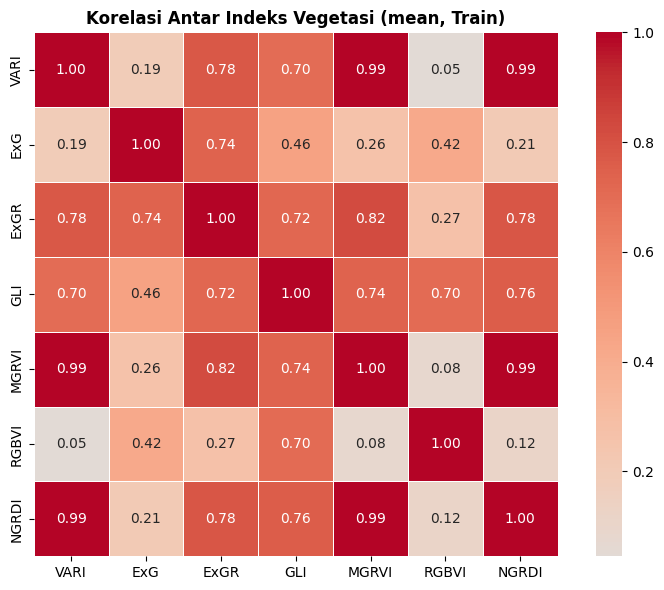

In [14]:
import seaborn as sns

mean_cols = [f"{vi}_mean" for vi in vi_names]
corr = train_sub[mean_cols].rename(columns={f"{v}_mean": v for v in vi_names}).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Korelasi Antar Indeks Vegetasi (mean, Train)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 🧪 Eksperimen: 7 VI × 5 Model (3 Kelas)

Pipeline setiap kombinasi:
1. Ambil fitur VI terpilih + GLCM (18 fitur per kombinasi)
2. **5-Fold Stratified CV** dengan `ImbPipeline`:
   - `RandomOverSampler` hanya aktif pada **fold training** — fold validasi tetap data asli
   - Mencegah *data leakage* yang menggelembungkan skor CV
3. Model akhir: ROS pada seluruh `trainval` → latih → evaluasi `test set`
4. Metrik utama: **F1-Macro** (robust terhadap class imbalance)

> ⚠️ **Catatan Label Encoding**: `LabelEncoder` mengurutkan secara alfabet →
> Generative=0, Mature=1, Vegetative=2. Semua output (`classification_report`,
> `ConfusionMatrixDisplay`) menggunakan `le.classes_` agar label benar.


In [15]:
# Label encoding
le = LabelEncoder()
le.fit(CLASS_ORDER)
df_all["y"] = le.transform(df_all["label"])
print("Classes:", list(le.classes_))
print("Encoding:", {c: le.transform([c])[0] for c in CLASS_ORDER})

# Split
train_df    = df_all[df_all["split"]=="train"].copy()
val_df      = df_all[df_all["split"]=="valid"].copy()
test_df     = df_all[df_all["split"]=="test"].copy()

# Gabungkan train+val untuk CV
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

y_trainval  = trainval_df["y"].values
y_test      = test_df["y"].values

print(f"\nTrain+Val (untuk CV): {len(trainval_df)} gambar")
print(f"Test (final check)  : {len(test_df)} gambar")
print(f"\nDistribusi Train+Val: {dict(zip(le.classes_, np.bincount(y_trainval)))}")
print(f"Distribusi Test     : {dict(zip(le.classes_, np.bincount(y_test)))}")


Classes: [np.str_('Generative'), np.str_('Mature'), np.str_('Vegetative')]
Encoding: {'Vegetative': np.int64(2), 'Generative': np.int64(0), 'Mature': np.int64(1)}

Train+Val (untuk CV): 537 gambar
Test (final check)  : 35 gambar

Distribusi Train+Val: {np.str_('Generative'): np.int64(146), np.str_('Mature'): np.int64(61), np.str_('Vegetative'): np.int64(330)}
Distribusi Test     : {np.str_('Generative'): np.int64(8), np.str_('Mature'): np.int64(5), np.str_('Vegetative'): np.int64(22)}


In [16]:
def get_models():
    """Model biasa — dipakai untuk prediksi final setelah training."""
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"
        ),
        "SVM_RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=5, gamma="scale",
                        class_weight="balanced", random_state=42, probability=True))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=7))
        ]),
        "LogReg": Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
        ]),
        "GradBoost": GradientBoostingClassifier(n_estimators=200, random_state=42),
    }

from imblearn.pipeline import Pipeline as ImbPipeline

def get_models_with_ros():
    """
    Model dengan ROS di dalam pipeline — dipakai untuk CV.
    ROS hanya diterapkan pada fold TRAIN di tiap fold,
    fold TEST tetap data asli → CV score lebih jujur, tidak overfitting.
    """
    return {
        "RandomForest": ImbPipeline([
            ("ros", RandomOverSampler(random_state=42)),
            ("clf", RandomForestClassifier(
                n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"))
        ]),
        "SVM_RBF": ImbPipeline([
            ("ros",    RandomOverSampler(random_state=42)),
            ("scaler", StandardScaler()),
            ("clf",    SVC(kernel="rbf", C=5, gamma="scale",
                           class_weight="balanced", random_state=42, probability=True))
        ]),
        "KNN": ImbPipeline([
            ("ros",    RandomOverSampler(random_state=42)),
            ("scaler", StandardScaler()),
            ("clf",    KNeighborsClassifier(n_neighbors=7))
        ]),
        "LogReg": ImbPipeline([
            ("ros",    RandomOverSampler(random_state=42)),
            ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
        ]),
        "GradBoost": ImbPipeline([
            ("ros", RandomOverSampler(random_state=42)),
            ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42))
        ]),
    }

MODEL_NAMES = list(get_models().keys())
VI_NAMES    = list(VI_REGISTRY.keys())
STAT_NAMES  = list(extract_vi_stats(np.array([0])).keys())
GLCM_NAMES  = [f'glcm_{p}_{s}' for p in ['contrast','correlation','energy','homogeneity']
                for s in ['mean','std']]

print(f"Model : {MODEL_NAMES}")
print(f"VI    : {VI_NAMES}")
print(f"Total kombinasi: {len(VI_NAMES)} × {len(MODEL_NAMES)} = {len(VI_NAMES)*len(MODEL_NAMES)}")
print("\n✅ get_models_with_ros() siap — ROS ada di dalam pipeline CV")


Model : ['RandomForest', 'SVM_RBF', 'KNN', 'LogReg', 'GradBoost']
VI    : ['VARI', 'ExG', 'ExGR', 'GLI', 'MGRVI', 'RGBVI', 'NGRDI']
Total kombinasi: 7 × 5 = 35

✅ get_models_with_ros() siap — ROS ada di dalam pipeline CV


### Jalankan Eksperimen (CV sebagai metrik utama)

In [17]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
exp_results = []

for vi_name in VI_NAMES:
    vi_feat_cols  = [f"{vi_name}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_trainval_vi = trainval_df[vi_feat_cols].values  # data ASLI, tanpa ROS dulu
    X_test_vi     = test_df[vi_feat_cols].values

    print(f"\n{'='*55}")
    print(f"  VI: {vi_name}  ({len(vi_feat_cols)} fitur)")
    print(f"  TrainVal asli: {dict(zip(le.classes_, np.bincount(y_trainval)))}")
    print(f"{'='*55}")

    for model_name, pipe_cv in get_models_with_ros().items():
        # ── CV pakai pipeline (ROS di dalam fold train) ───────────────────
        cv_scores = cross_validate(
            pipe_cv, X_trainval_vi, y_trainval, cv=skf,
            scoring=["accuracy", "f1_macro", "f1_weighted"], n_jobs=-1
        )
        cv_acc     = cv_scores["test_accuracy"].mean()
        cv_acc_std = cv_scores["test_accuracy"].std()
        cv_f1      = cv_scores["test_f1_macro"].mean()
        cv_f1_std  = cv_scores["test_f1_macro"].std()
        cv_f1w     = cv_scores["test_f1_weighted"].mean()

        # ── Final training: ROS manual lalu fit model biasa ───────────────
        ros_final = RandomOverSampler(random_state=42)
        X_tv_sm, y_tv_sm = ros_final.fit_resample(X_trainval_vi, y_trainval)
        clf_final = get_models()[model_name]
        clf_final.fit(X_tv_sm, y_tv_sm)

        # ── Evaluasi test set ─────────────────────────────────────────────
        test_pred = clf_final.predict(X_test_vi)
        test_acc  = accuracy_score(y_test, test_pred)
        test_f1   = f1_score(y_test, test_pred, average="macro")
        test_f1w  = f1_score(y_test, test_pred, average="weighted")

        exp_results.append({
            "vi":               vi_name,
            "model":            model_name,
            "cv_acc":           round(cv_acc, 4),
            "cv_acc_std":       round(cv_acc_std, 4),
            "cv_f1_macro":      round(cv_f1, 4),
            "cv_f1_std":        round(cv_f1_std, 4),
            "cv_f1_weighted":   round(cv_f1w, 4),
            "test_acc":         round(test_acc, 4),
            "test_f1_macro":    round(test_f1, 4),
            "test_f1_weighted": round(test_f1w, 4),
        })

        print(f"  {model_name:15s}  "
              f"CV_acc={cv_acc:.4f}±{cv_acc_std:.4f}  "
              f"CV_F1={cv_f1:.4f}±{cv_f1_std:.4f}  "
              f"test_acc={test_acc:.4f}")

exp_df = pd.DataFrame(exp_results)
print(f"\n✅ Eksperimen selesai. Total kombinasi: {len(exp_df)}")



  VI: VARI  (18 fitur)
  TrainVal asli: {np.str_('Generative'): np.int64(146), np.str_('Mature'): np.int64(61), np.str_('Vegetative'): np.int64(330)}
  RandomForest     CV_acc=0.9497±0.0128  CV_F1=0.9506±0.0175  test_acc=0.9143
  SVM_RBF          CV_acc=0.9609±0.0092  CV_F1=0.9599±0.0119  test_acc=0.9714
  KNN              CV_acc=0.9070±0.0201  CV_F1=0.9013±0.0192  test_acc=0.9714
  LogReg           CV_acc=0.9534±0.0118  CV_F1=0.9499±0.0094  test_acc=0.9714
  GradBoost        CV_acc=0.9478±0.0140  CV_F1=0.9478±0.0152  test_acc=0.8857

  VI: ExG  (18 fitur)
  TrainVal asli: {np.str_('Generative'): np.int64(146), np.str_('Mature'): np.int64(61), np.str_('Vegetative'): np.int64(330)}
  RandomForest     CV_acc=0.9423±0.0089  CV_F1=0.9167±0.0230  test_acc=0.9143
  SVM_RBF          CV_acc=0.9758±0.0094  CV_F1=0.9661±0.0149  test_acc=0.9429
  KNN              CV_acc=0.9516±0.0189  CV_F1=0.9290±0.0332  test_acc=0.8857
  LogReg           CV_acc=0.9646±0.0069  CV_F1=0.9528±0.0178  test_acc=0.88

## 📋 Tabel Hasil & Ranking

In [18]:
# Harmonic mean CV-Test sebagai ukuran konsistensi model
exp_df["cv_test_hmean"] = (
    2 * exp_df["cv_f1_macro"] * exp_df["test_f1_macro"]
    / (exp_df["cv_f1_macro"] + exp_df["test_f1_macro"] + 1e-9)
).round(4)

# Ranking 1: CV F1-Macro (metrik statistik utama)
exp_df_sorted = exp_df.sort_values("cv_f1_macro", ascending=False).reset_index(drop=True)
exp_df_sorted.index += 1

print("=== TOP 10 — Ranking CV F1-Macro (Metrik Statistik Utama) ===")
display(exp_df_sorted[["vi","model","cv_acc","cv_acc_std",
                        "cv_f1_macro","cv_f1_std","test_acc","test_f1_macro",
                        "cv_test_hmean"]].head(10))

# Ranking 2: Harmonic mean CV↔Test (rekomendasi praktis / IoT)
exp_df_practical = exp_df.sort_values("cv_test_hmean", ascending=False).reset_index(drop=True)
exp_df_practical.index += 1

print("\n=== TOP 10 — Ranking Harmonic Mean CV↔Test F1 (Rekomendasi Praktis / IoT) ===")
print("(Model yang konsisten di CV maupun test set — penting untuk deployment)")
display(exp_df_practical[["vi","model","cv_f1_macro","test_f1_macro","cv_test_hmean"]].head(10))

EXP_CSV = "/content/experiment_3class_results.csv"
exp_df_sorted.to_csv(EXP_CSV, index=True)
print(f"\nSaved: {EXP_CSV}")


=== TOP 10 — Ranking CV F1-Macro (Metrik Statistik Utama) ===


,vi,model,cv_acc,cv_acc_std,cv_f1_macro,cv_f1_std,test_acc,test_f1_macro,cv_test_hmean
1,ExGR,LogReg,0.9851,0.0151,0.9808,0.0204,0.9143,0.8504,0.9110
2,ExGR,SVM_RBF,0.9851,0.0095,0.9800,0.0103,0.9143,0.8818,0.9283
3,ExGR,GradBoost,0.9758,0.0172,0.9668,0.0274,0.8857,0.7981,0.8744
4,ExG,SVM_RBF,0.9758,0.0094,0.9661,0.0149,0.9429,0.8917,0.9274
5,ExGR,RandomForest,0.9720,0.0168,0.9658,0.0184,0.8857,0.7981,0.8740
6,ExGR,KNN,0.9740,0.0160,0.9633,0.0215,0.9143,0.8818,0.9208
7,MGRVI,SVM_RBF,0.9609,0.0070,0.9602,0.0117,0.9714,0.9704,0.9653
8,VARI,SVM_RBF,0.9609,0.0092,0.9599,0.0119,0.9714,0.9704,0.9651
9,NGRDI,SVM_RBF,0.9571,0.0096,0.9570,0.0102,1.0000,1.0000,0.9780
10,ExG,LogReg,0.9646,0.0069,0.9528,0.0178,0.8857,0.7937,0.8660



=== TOP 10 — Ranking Harmonic Mean CV↔Test F1 (Rekomendasi Praktis / IoT) ===
(Model yang konsisten di CV maupun test set — penting untuk deployment)


,vi,model,cv_f1_macro,test_f1_macro,cv_test_hmean
1,NGRDI,SVM_RBF,0.9570,1.0000,0.9780
2,MGRVI,SVM_RBF,0.9602,0.9704,0.9653
3,VARI,SVM_RBF,0.9599,0.9704,0.9651
4,VARI,LogReg,0.9499,0.9704,0.9600
5,GLI,SVM_RBF,0.9505,0.9379,0.9442
6,NGRDI,LogReg,0.9366,0.9432,0.9399
7,MGRVI,LogReg,0.9294,0.9432,0.9362
8,VARI,KNN,0.9013,0.9704,0.9346
9,ExGR,SVM_RBF,0.9800,0.8818,0.9283
10,ExG,SVM_RBF,0.9661,0.8917,0.9274



Saved: /content/experiment_3class_results.csv


## 🗺️ Heatmap Performa: VI × Model

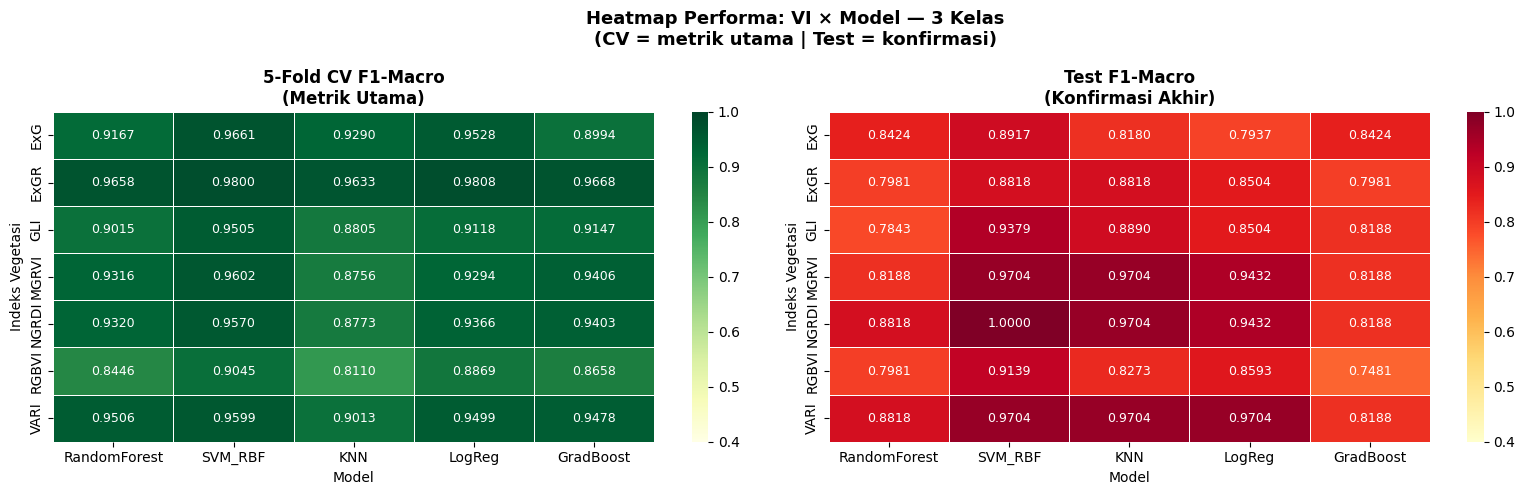

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_cv_f1   = exp_df.pivot(index="vi", columns="model", values="cv_f1_macro")[MODEL_NAMES]
pivot_test_f1 = exp_df.pivot(index="vi", columns="model", values="test_f1_macro")[MODEL_NAMES]

sns.heatmap(pivot_cv_f1, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, ax=axes[0], vmin=0.4, vmax=1.0, annot_kws={"size":9})
axes[0].set_title("5-Fold CV F1-Macro\n(Metrik Utama)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Indeks Vegetasi")

sns.heatmap(pivot_test_f1, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], vmin=0.4, vmax=1.0, annot_kws={"size":9})
axes[1].set_title("Test F1-Macro\n(Konfirmasi Akhir)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Indeks Vegetasi")

plt.suptitle("Heatmap Performa: VI × Model — 3 Kelas\n(CV = metrik utama | Test = konfirmasi)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 📊 Ranking VI dan Model

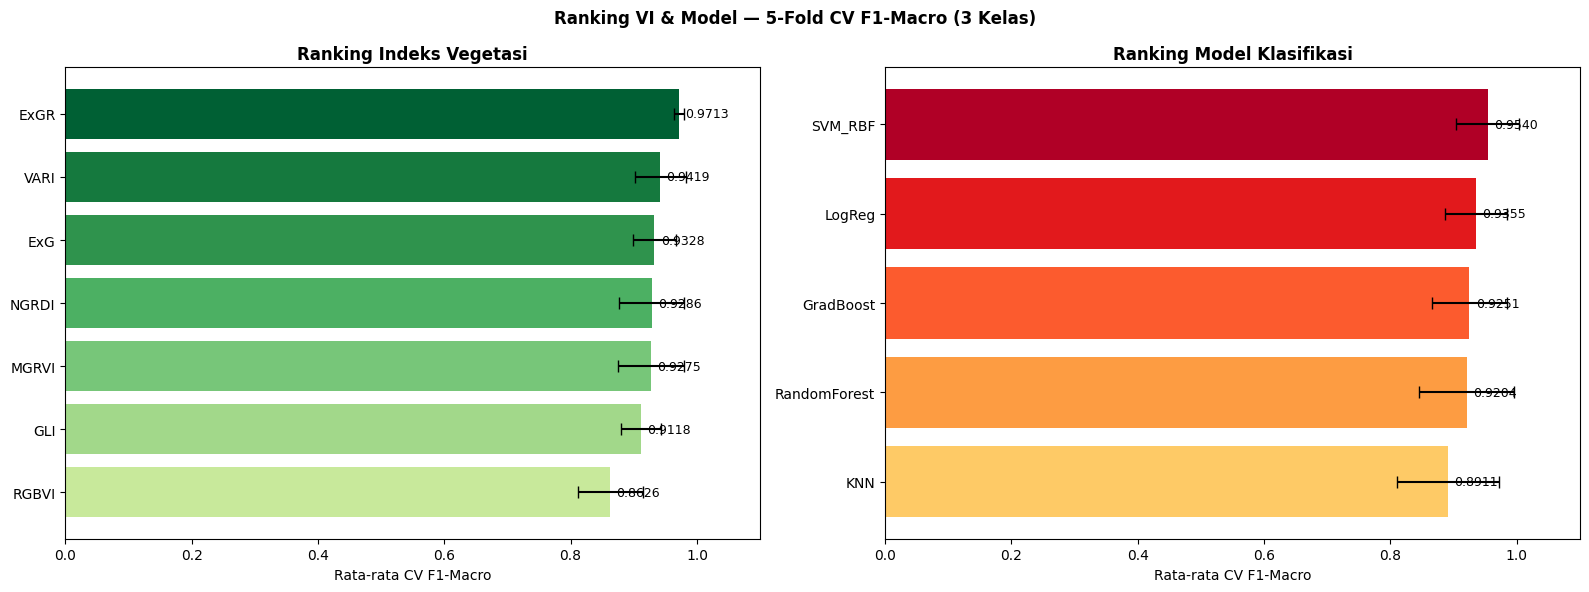

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vi_avg = exp_df.groupby("vi")["cv_f1_macro"].agg(["mean","min"]).reset_index()
vi_avg = vi_avg.sort_values("mean", ascending=True)
colors_vi = plt.cm.YlGn(np.linspace(0.3, 0.9, len(vi_avg)))
bars = axes[0].barh(vi_avg["vi"], vi_avg["mean"], color=colors_vi,
                    xerr=(vi_avg["mean"]-vi_avg["min"]).values, capsize=4)
axes[0].set_xlabel("Rata-rata CV F1-Macro")
axes[0].set_title("Ranking Indeks Vegetasi", fontweight="bold")
axes[0].set_xlim(0, 1.1)
for bar, val in zip(bars, vi_avg["mean"]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

model_avg = exp_df.groupby("model")["cv_f1_macro"].agg(["mean","min"]).reset_index()
model_avg = model_avg.sort_values("mean", ascending=True)
colors_m  = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(model_avg)))
bars2 = axes[1].barh(model_avg["model"], model_avg["mean"], color=colors_m,
                     xerr=(model_avg["mean"]-model_avg["min"]).values, capsize=4)
axes[1].set_xlabel("Rata-rata CV F1-Macro")
axes[1].set_title("Ranking Model Klasifikasi", fontweight="bold")
axes[1].set_xlim(0, 1.1)
for bar, val in zip(bars2, model_avg["mean"]):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("Ranking VI & Model — 5-Fold CV F1-Macro (3 Kelas)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Grouped Bar: F1 per Model untuk Tiap VI

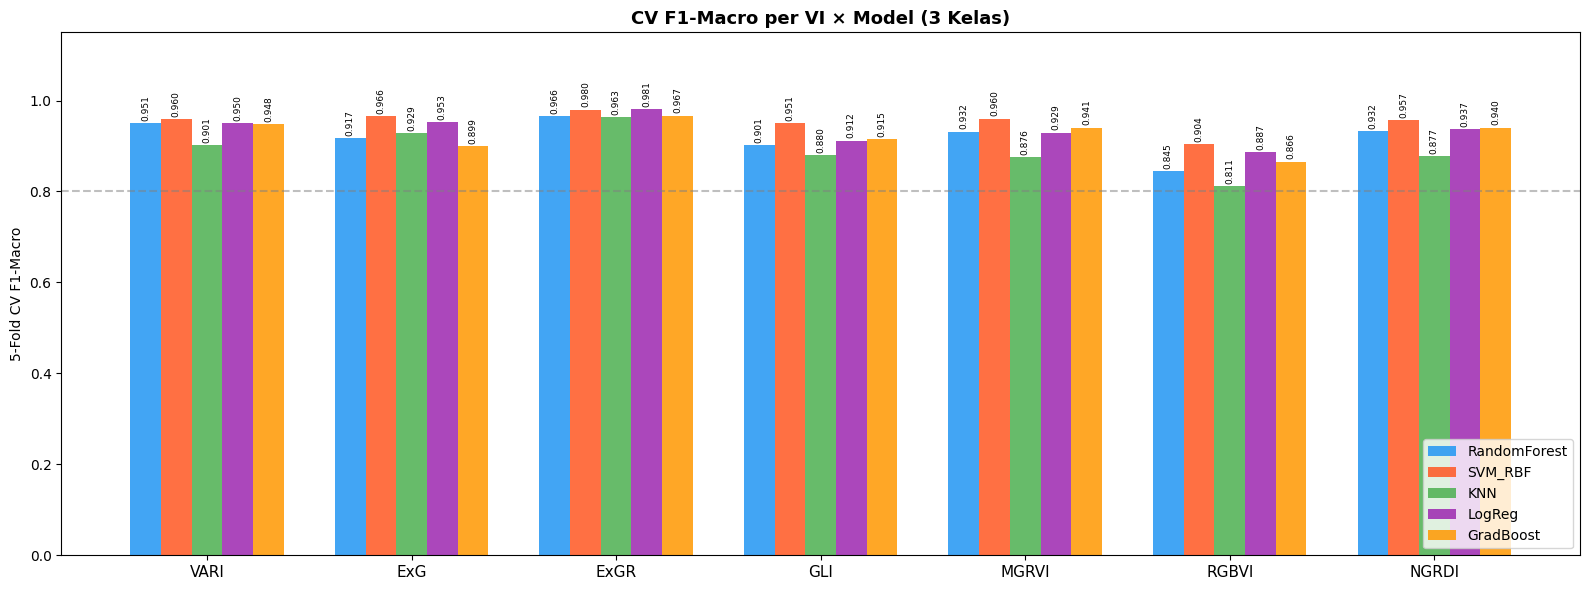

In [21]:
model_colors = {
    "RandomForest": "#2196F3",
    "SVM_RBF":      "#FF5722",
    "KNN":          "#4CAF50",
    "LogReg":       "#9C27B0",
    "GradBoost":    "#FF9800",
}
x     = np.arange(len(VI_NAMES))
width = 0.15
fig, ax = plt.subplots(figsize=(16, 6))

for i, model_name in enumerate(MODEL_NAMES):
    vals = [exp_df[(exp_df["vi"]==vi) & (exp_df["model"]==model_name)]["cv_f1_macro"].values[0]
            for vi in VI_NAMES]
    offset = (i - 2) * width
    rects  = ax.bar(x + offset, vals, width, label=model_name,
                    color=model_colors[model_name], alpha=0.85)
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(VI_NAMES, fontsize=11)
ax.set_ylabel("5-Fold CV F1-Macro")
ax.set_title("CV F1-Macro per VI × Model (3 Kelas)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 🏆 Analisis Mendalam — Kombinasi Terbaik

In [22]:
best_row   = exp_df_sorted.iloc[0]
best_vi    = best_row["vi"]
best_model = best_row["model"]

# Rekomendasi praktis (konsistensi CV-Test, cocok untuk IoT)
practical_row   = exp_df_practical.iloc[0]
prac_vi         = practical_row["vi"]
prac_model      = practical_row["model"]

print(f"🏆 Kombinasi Terbaik secara Statistik (CV F1-Macro tertinggi)")
print(f"   VI      : {best_vi}  |  Model : {best_model}")
print(f"   CV F1   : {best_row['cv_f1_macro']} ± {best_row['cv_f1_std']}")
print(f"   Test F1 : {best_row['test_f1_macro']}  |  HMean CV↔Test : {best_row['cv_test_hmean']}")

print(f"\n📱 Kombinasi Rekomendasi untuk IoT (Harmonic Mean CV↔Test tertinggi)")
print(f"   VI      : {prac_vi}  |  Model : {prac_model}")
print(f"   CV F1   : {practical_row['cv_f1_macro']} ± {practical_row['cv_f1_std']}")
print(f"   Test F1 : {practical_row['test_f1_macro']}  |  HMean CV↔Test : {practical_row['cv_test_hmean']}")

# ── Analisis mendalam: model IoT (konsistensi lebih penting untuk deployment) ──
vi_feat_cols_best = [f"{prac_vi}_{s}" for s in STAT_NAMES] + GLCM_NAMES
X_tv_best = trainval_df[vi_feat_cols_best].values
X_te_best = test_df[vi_feat_cols_best].values

# CV predictions — pipeline (ROS di dalam fold, tidak leakage)
print(f"\n⏳ Menghitung CV predictions: {prac_vi} + {prac_model} ...")
y_cv_pred = cross_val_predict(
    get_models_with_ros()[prac_model],
    X_tv_best, y_trainval, cv=skf, n_jobs=-1
)

# PENTING: gunakan le.classes_ — LabelEncoder sort alfabet (Generative=0,Mature=1,Vegetative=2)
print(f"\n=== Classification Report — 5-Fold CV (n={len(y_trainval)}, data asli) ===")
print(classification_report(y_trainval, y_cv_pred, target_names=list(le.classes_)))

# Final model untuk test
ros_best = RandomOverSampler(random_state=42)
X_tv_sm, y_tv_sm = ros_best.fit_resample(X_tv_best, y_trainval)
best_clf = get_models()[prac_model]
best_clf.fit(X_tv_sm, y_tv_sm)
y_pred_best = best_clf.predict(X_te_best)

print(f"=== Classification Report — Test Set (n={len(y_test)}, konfirmasi) ===")
print(classification_report(y_test, y_pred_best, target_names=list(le.classes_)))

print("\n=== Detail per Fold CV ===")
cv_detail = cross_validate(
    get_models_with_ros()[prac_model], X_tv_best, y_trainval, cv=skf,
    scoring=["accuracy","f1_macro"], n_jobs=-1
)
for i in range(5):
    print(f"  Fold {i+1}: acc={cv_detail['test_accuracy'][i]:.4f}  f1={cv_detail['test_f1_macro'][i]:.4f}")
print(f"  Mean : acc={cv_detail['test_accuracy'].mean():.4f}  f1={cv_detail['test_f1_macro'].mean():.4f}")
print(f"  Std  : acc={cv_detail['test_accuracy'].std():.4f}  f1={cv_detail['test_f1_macro'].std():.4f}")


🏆 Kombinasi Terbaik secara Statistik (CV F1-Macro tertinggi)
   VI      : ExGR  |  Model : LogReg
   CV F1   : 0.9808 ± 0.0204
   Test F1 : 0.8504  |  HMean CV↔Test : 0.911

📱 Kombinasi Rekomendasi untuk IoT (Harmonic Mean CV↔Test tertinggi)
   VI      : NGRDI  |  Model : SVM_RBF
   CV F1   : 0.957 ± 0.0102
   Test F1 : 1.0  |  HMean CV↔Test : 0.978

⏳ Menghitung CV predictions: NGRDI + SVM_RBF ...

=== Classification Report — 5-Fold CV (n=537, data asli) ===
              precision    recall  f1-score   support

  Generative       0.95      0.89      0.92       146
      Mature       0.98      0.98      0.98        61
  Vegetative       0.96      0.98      0.97       330

    accuracy                           0.96       537
   macro avg       0.96      0.95      0.96       537
weighted avg       0.96      0.96      0.96       537

=== Classification Report — Test Set (n=35, konfirmasi) ===
              precision    recall  f1-score   support

  Generative       1.00      1.00      1

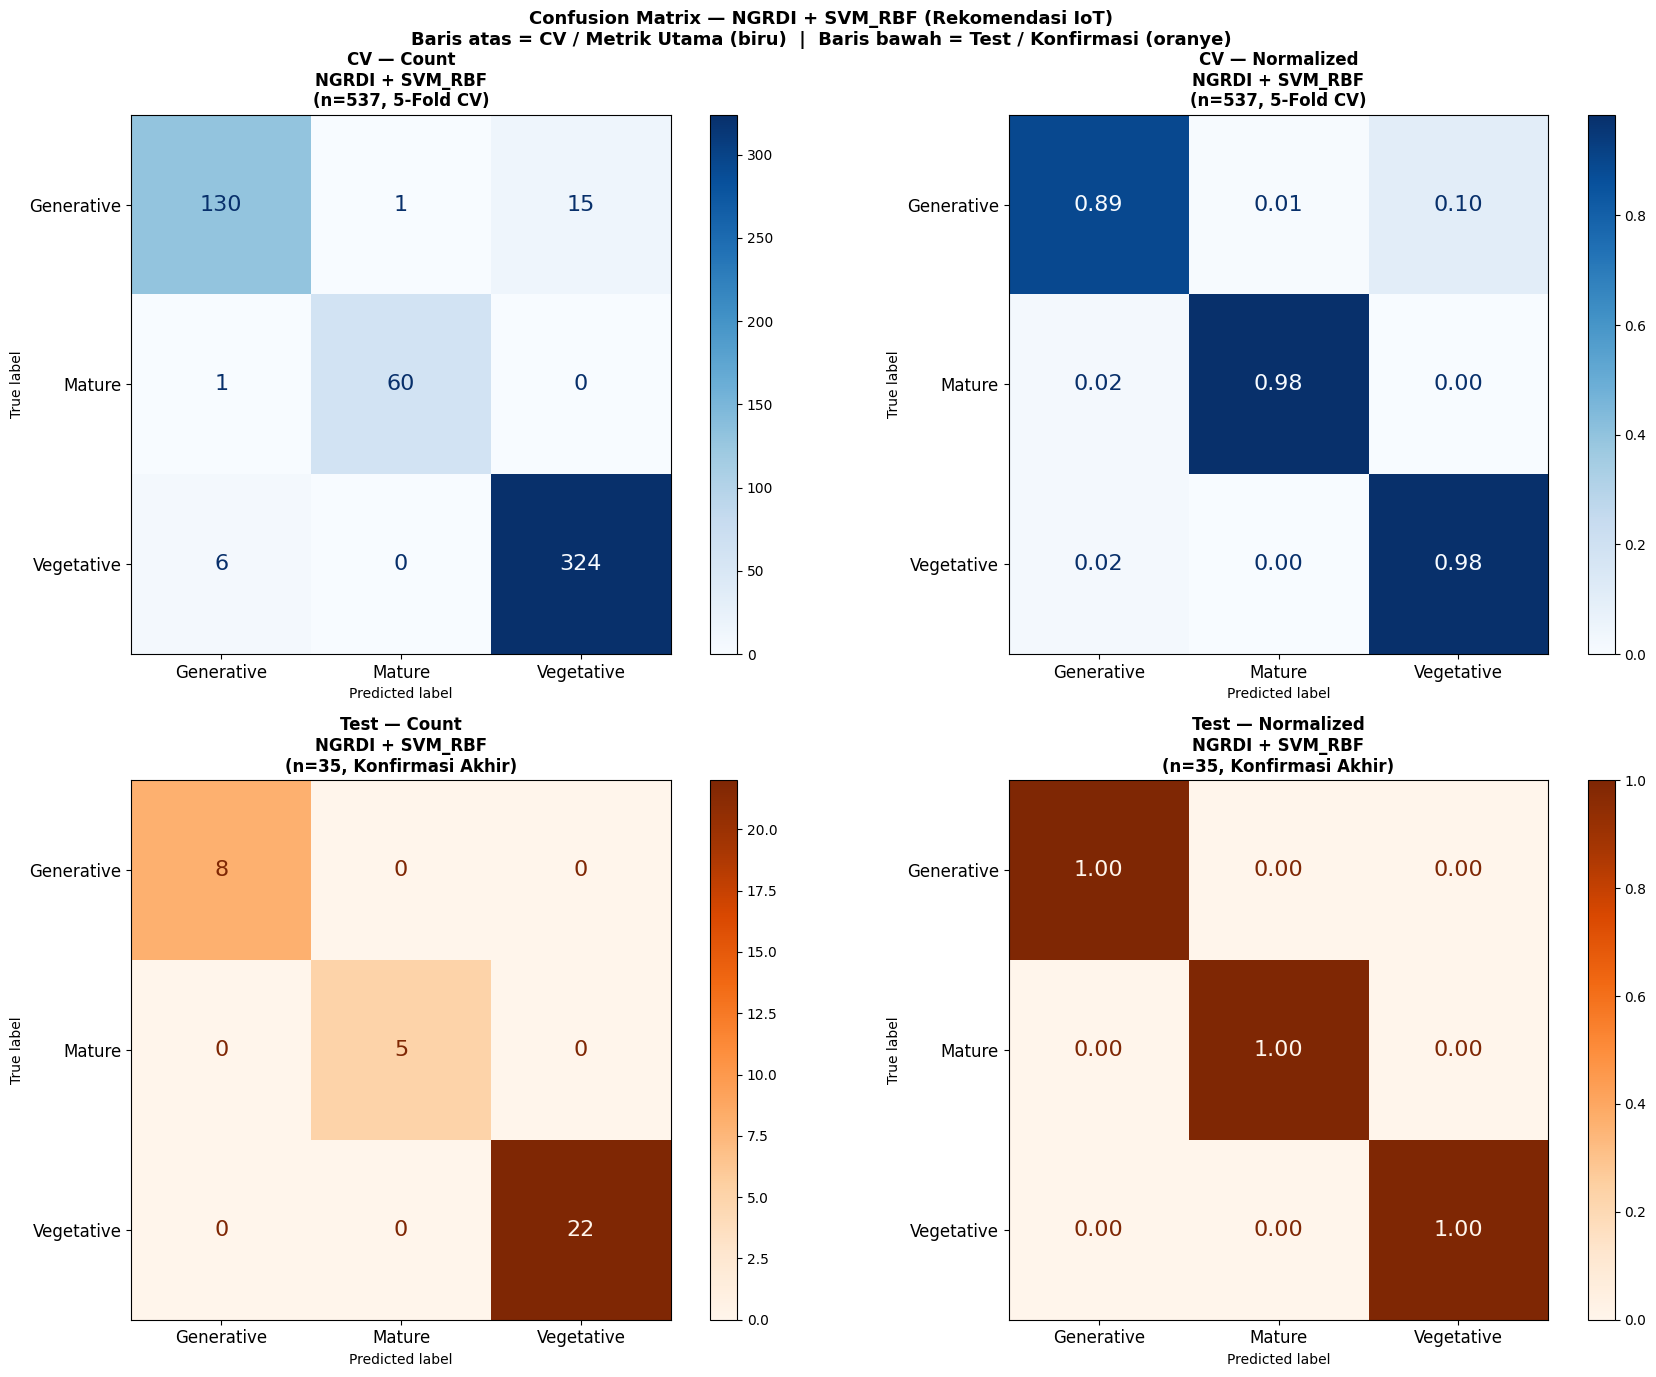

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

# le.classes_ = ['Generative','Mature','Vegetative'] — label benar sesuai encoding
DISP_LABELS = list(le.classes_)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Baris atas: CV (evaluasi utama)
cm_cv      = confusion_matrix(y_trainval, y_cv_pred)
cm_cv_norm = confusion_matrix(y_trainval, y_cv_pred, normalize="true")

disp_cv = ConfusionMatrixDisplay(cm_cv, display_labels=DISP_LABELS)
disp_cv.plot(ax=axes[0][0], colorbar=True, cmap="Blues")
axes[0][0].set_title(
    f"CV — Count\n{prac_vi} + {prac_model}\n(n={len(y_trainval)}, 5-Fold CV)",
    fontweight="bold", fontsize=12)
axes[0][0].tick_params(axis='both', labelsize=12)
for t in disp_cv.text_.ravel(): t.set_fontsize(16)

disp_cv_n = ConfusionMatrixDisplay(cm_cv_norm, display_labels=DISP_LABELS)
disp_cv_n.plot(ax=axes[0][1], colorbar=True, cmap="Blues", values_format=".2f")
axes[0][1].set_title(
    f"CV — Normalized\n{prac_vi} + {prac_model}\n(n={len(y_trainval)}, 5-Fold CV)",
    fontweight="bold", fontsize=12)
axes[0][1].tick_params(axis='both', labelsize=12)
for t in disp_cv_n.text_.ravel(): t.set_fontsize(16)

# Baris bawah: Test (konfirmasi)
cm_test      = confusion_matrix(y_test, y_pred_best)
cm_test_norm = confusion_matrix(y_test, y_pred_best, normalize="true")

disp_te = ConfusionMatrixDisplay(cm_test, display_labels=DISP_LABELS)
disp_te.plot(ax=axes[1][0], colorbar=True, cmap="Oranges")
axes[1][0].set_title(
    f"Test — Count\n{prac_vi} + {prac_model}\n(n={len(y_test)}, Konfirmasi Akhir)",
    fontweight="bold", fontsize=12)
axes[1][0].tick_params(axis='both', labelsize=12)
for t in disp_te.text_.ravel(): t.set_fontsize(16)

disp_te_n = ConfusionMatrixDisplay(cm_test_norm, display_labels=DISP_LABELS)
disp_te_n.plot(ax=axes[1][1], colorbar=True, cmap="Oranges", values_format=".2f")
axes[1][1].set_title(
    f"Test — Normalized\n{prac_vi} + {prac_model}\n(n={len(y_test)}, Konfirmasi Akhir)",
    fontweight="bold", fontsize=12)
axes[1][1].tick_params(axis='both', labelsize=12)
for t in disp_te_n.text_.ravel(): t.set_fontsize(16)

plt.suptitle(
    f"Confusion Matrix — {prac_vi} + {prac_model} (Rekomendasi IoT)\n"
    f"Baris atas = CV / Metrik Utama (biru)  |  Baris bawah = Test / Konfirmasi (oranye)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Perbandingan Top 3 Kombinasi

Top 3 Kombinasi Terbaik (CV F1-Macro):


,vi,model,cv_f1_macro,cv_f1_std,test_acc,test_f1_macro,cv_test_hmean
1,ExGR,LogReg,0.9808,0.0204,0.9143,0.8504,0.9110
2,ExGR,SVM_RBF,0.9800,0.0103,0.9143,0.8818,0.9283
3,ExGR,GradBoost,0.9668,0.0274,0.8857,0.7981,0.8744


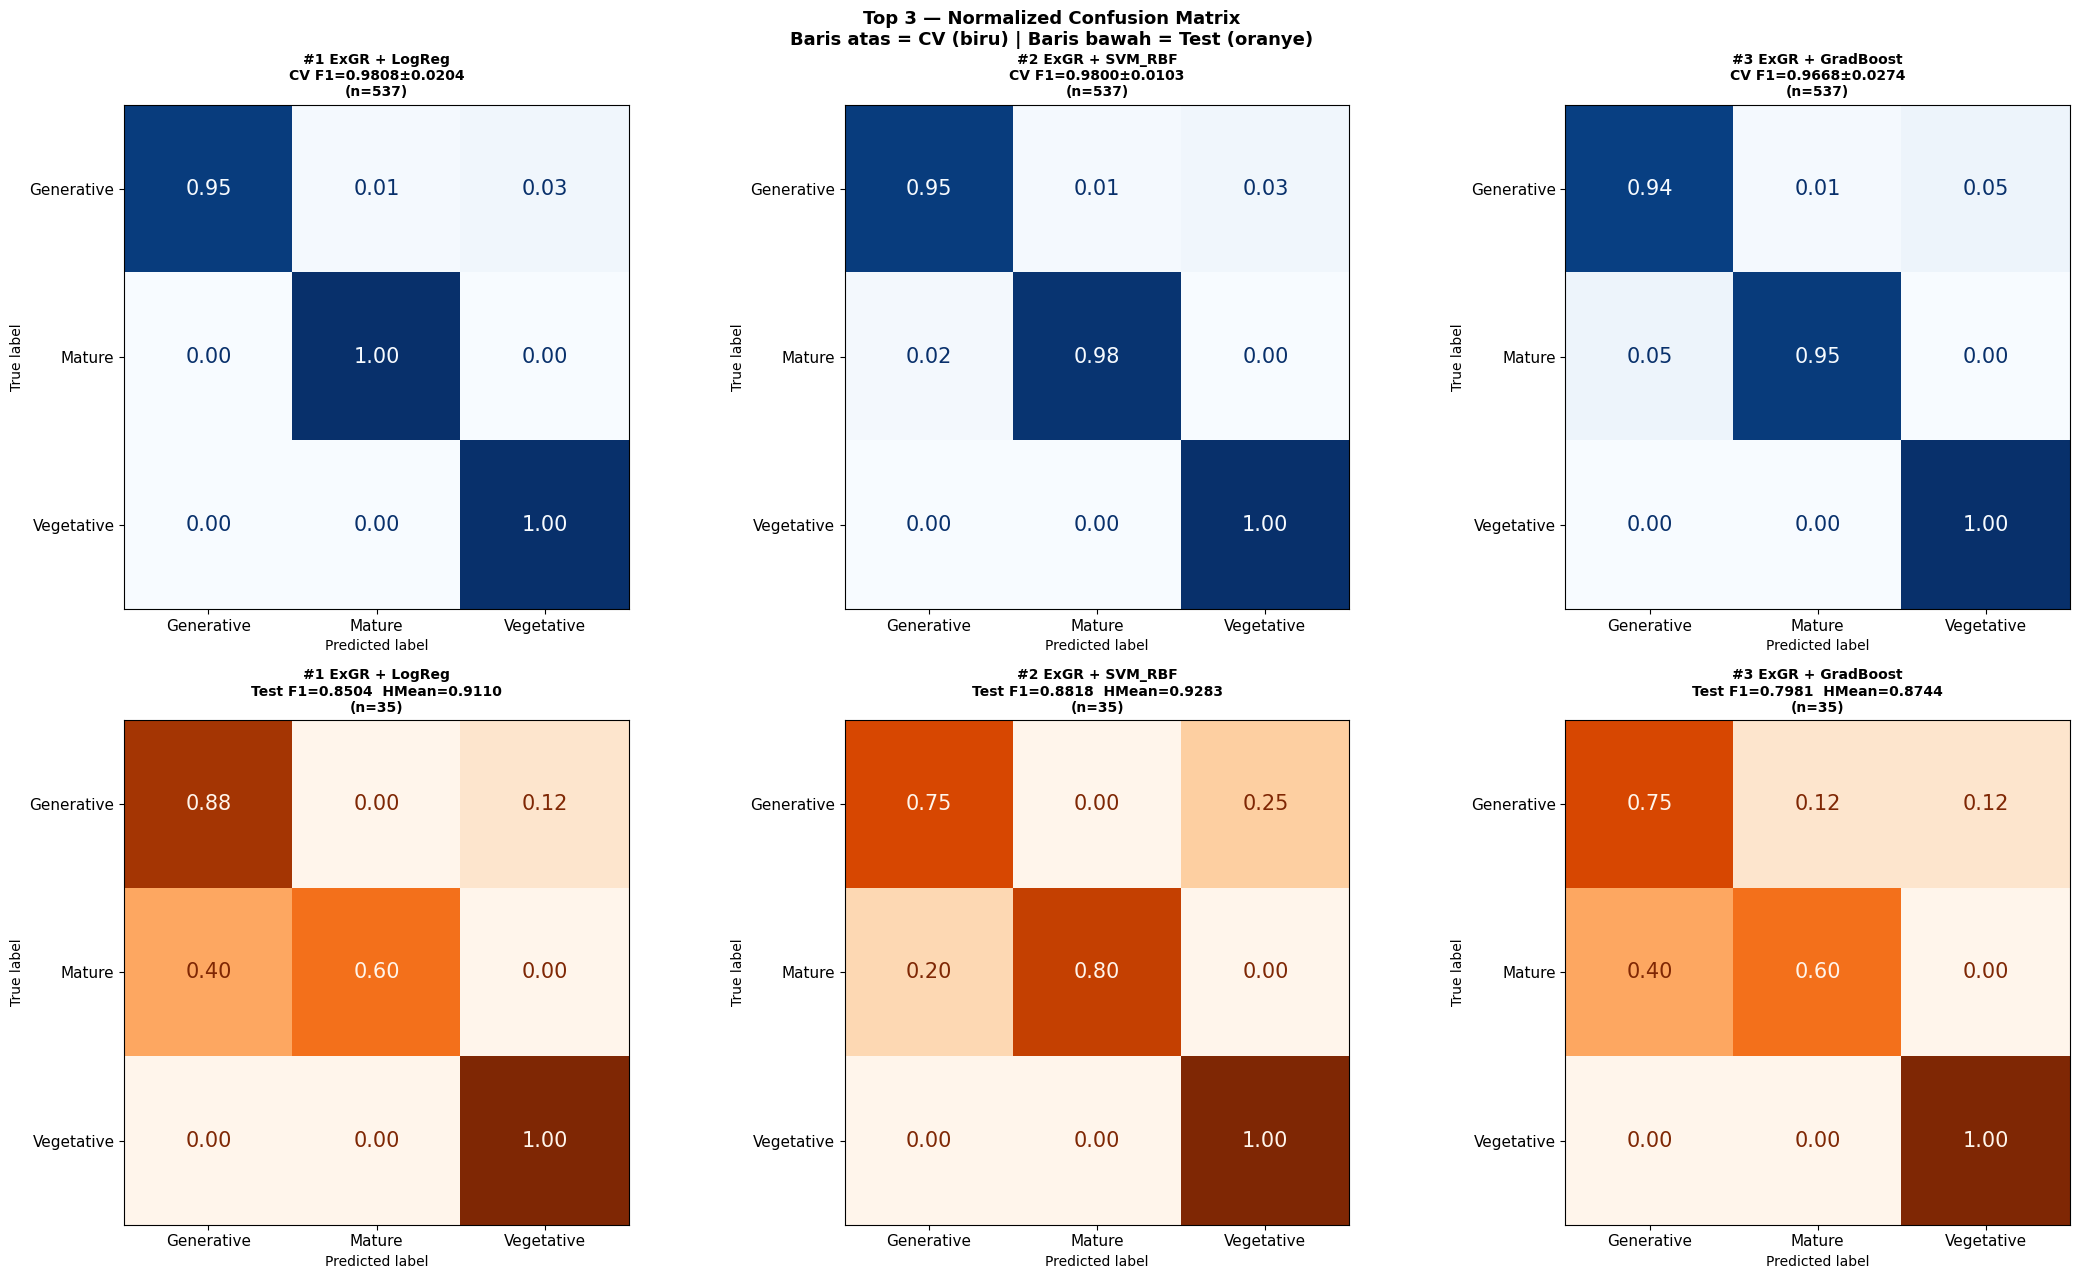

In [24]:
top3 = exp_df_sorted.head(3)
print("Top 3 Kombinasi Terbaik (CV F1-Macro):")
display(top3[["vi","model","cv_f1_macro","cv_f1_std","test_acc","test_f1_macro","cv_test_hmean"]])

DISP_LABELS = list(le.classes_)
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

for idx_plot, (_, row) in enumerate(top3.iterrows()):
    vi      = row["vi"]
    mod     = row["model"]
    vi_cols = [f"{vi}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_tv_i = trainval_df[vi_cols].values
    X_te_i = test_df[vi_cols].values

    # CV predictions — pipeline (ROS di dalam fold)
    y_cv_i = cross_val_predict(
        get_models_with_ros()[mod], X_tv_i, y_trainval, cv=skf, n_jobs=-1
    )

    # Final model untuk test
    ros_i = RandomOverSampler(random_state=42)
    X_si, y_si = ros_i.fit_resample(X_tv_i, y_trainval)
    clf_i = get_models()[mod]
    clf_i.fit(X_si, y_si)
    pred_te_i = clf_i.predict(X_te_i)

    # Baris atas: CV
    cm_cv_i = confusion_matrix(y_trainval, y_cv_i, normalize="true")
    disp_cv_i = ConfusionMatrixDisplay(cm_cv_i, display_labels=DISP_LABELS)
    disp_cv_i.plot(ax=axes[0][idx_plot], colorbar=False, cmap="Blues", values_format=".2f")
    axes[0][idx_plot].set_title(
        f"#{idx_plot+1} {vi} + {mod}\nCV F1={row['cv_f1_macro']:.4f}±{row['cv_f1_std']:.4f}\n(n={len(y_trainval)})",
        fontsize=10, fontweight="bold")
    axes[0][idx_plot].tick_params(axis='both', labelsize=11)
    for t in disp_cv_i.text_.ravel(): t.set_fontsize(15)

    # Baris bawah: Test
    cm_te_i = confusion_matrix(y_test, pred_te_i, normalize="true")
    disp_te_i = ConfusionMatrixDisplay(cm_te_i, display_labels=DISP_LABELS)
    disp_te_i.plot(ax=axes[1][idx_plot], colorbar=False, cmap="Oranges", values_format=".2f")
    axes[1][idx_plot].set_title(
        f"#{idx_plot+1} {vi} + {mod}\nTest F1={row['test_f1_macro']:.4f}  HMean={row['cv_test_hmean']:.4f}\n(n={len(y_test)})",
        fontsize=10, fontweight="bold")
    axes[1][idx_plot].tick_params(axis='both', labelsize=11)
    for t in disp_te_i.text_.ravel(): t.set_fontsize(15)

plt.suptitle(
    "Top 3 — Normalized Confusion Matrix\n"
    "Baris atas = CV (biru) | Baris bawah = Test (oranye)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 🔍 Feature Importance — Kombinasi Terbaik

In [25]:
raw_clf = best_clf.steps[-1][1] if hasattr(best_clf, "steps") else best_clf

if hasattr(raw_clf, "feature_importances_"):
    fi         = raw_clf.feature_importances_
    feat_names = vi_feat_cols_best
    idx_sorted = np.argsort(fi)[::-1]
    top_n      = min(20, len(fi))

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(range(top_n), fi[idx_sorted[:top_n]][::-1],
            color=plt.cm.YlGn(np.linspace(0.3, 0.9, top_n)))
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feat_names[i] for i in idx_sorted[:top_n]][::-1])
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top {top_n} Fitur Terpenting — {best_vi} + {best_model}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("Top 5 fitur:")
    for i in range(5):
        print(f"  {i+1}. {feat_names[idx_sorted[i]]:35s} = {fi[idx_sorted[i]]:.4f}")
else:
    print(f"{best_model} tidak berbasis tree — feature importance tidak tersedia langsung.")


LogReg tidak berbasis tree — feature importance tidak tersedia langsung.


## 🔬 Analisis Misclassification — Kombinasi Terbaik

In [26]:
test_df_r = test_df.reset_index(drop=True).copy()
test_df_r["pred"]    = le.inverse_transform(y_pred_best)
test_df_r["true"]    = le.inverse_transform(y_test)
test_df_r["correct"] = test_df_r["pred"] == test_df_r["true"]

wrong = test_df_r[~test_df_r["correct"]].reset_index(drop=True)
print(f"Salah prediksi : {len(wrong)} / {len(test_df_r)} gambar test")
print(f"Test Accuracy  : {test_df_r['correct'].mean():.4f}")
print(f"\n⚠️  Test set kecil (n={len(test_df_r)}), evaluasi utama dari CV 5-fold\n")

if len(wrong) > 0:
    print("=== Pola Kesalahan ===")
    display(wrong.groupby(["true","pred"]).size().reset_index(name="count"))
else:
    print("Tidak ada misclassification pada test set!")

n_show = min(8, len(wrong))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i in range(n_show):
        row = wrong.iloc[i]
        rgb = read_rgb(row["path"])
        if rgb is not None:
            axes[i].imshow(rgb)
        axes[i].set_title(f"True: {row['true']}\nPred: {row['pred']}", fontsize=9, color="red")
        axes[i].axis("off")
    for i in range(n_show, 8):
        axes[i].axis("off")
    plt.suptitle(f"Misclassification — {best_vi} + {best_model}", fontweight="bold")
    plt.tight_layout()
    plt.show()


Salah prediksi : 0 / 35 gambar test
Test Accuracy  : 1.0000

⚠️  Test set kecil (n=35), evaluasi utama dari CV 5-fold

Tidak ada misclassification pada test set!


## 📊 Heatmap CV F1-Macro ± Std per Kombinasi

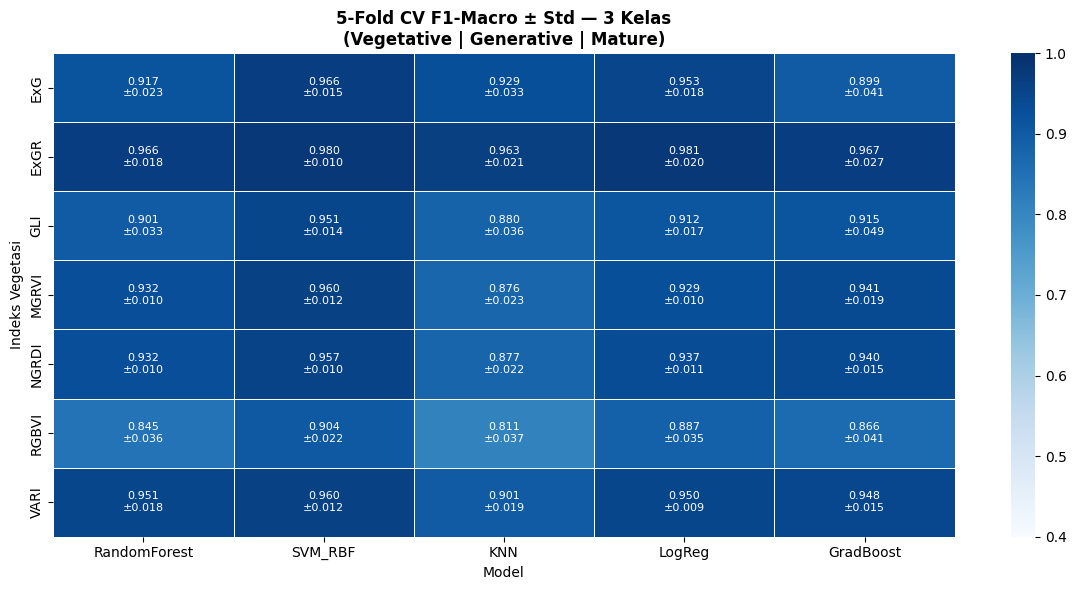

In [27]:
annot_data         = exp_df.copy()
annot_data["label"] = annot_data.apply(
    lambda r: f"{r['cv_f1_macro']:.3f}\n±{r['cv_f1_std']:.3f}", axis=1
)
pivot_annot = annot_data.pivot(index="vi", columns="model", values="label")[MODEL_NAMES]
pivot_val   = exp_df.pivot(index="vi", columns="model", values="cv_f1_macro")[MODEL_NAMES]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_val, annot=pivot_annot, fmt="", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0, annot_kws={"size": 8})
ax.set_title("5-Fold CV F1-Macro ± Std — 3 Kelas\n(Vegetative | Generative | Mature)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Indeks Vegetasi")
plt.tight_layout()
plt.show()


## 📝 Ringkasan Eksperimen

In [28]:
print("=" * 65)
print("  RINGKASAN EKSPERIMEN — 3 KELAS")
print("  Vegetative | Generative | Mature")
print("  Metrik utama: 5-Fold Cross-Validation F1-Macro")
print("=" * 65)

print("\n📊 Rata-rata CV F1-Macro per Indeks Vegetasi:")
vi_rank = exp_df.groupby("vi")["cv_f1_macro"].mean().sort_values(ascending=False)
for i, (vi, f1) in enumerate(vi_rank.items(), 1):
    print(f"  {i}. {vi:8s}: {f1:.4f}")

print("\n🤖 Rata-rata CV F1-Macro per Model:")
model_rank = exp_df.groupby("model")["cv_f1_macro"].mean().sort_values(ascending=False)
for i, (m, f1) in enumerate(model_rank.items(), 1):
    print(f"  {i}. {m:15s}: {f1:.4f}")

best = exp_df_sorted.iloc[0]
print(f"\n🏆 Kombinasi Terbaik:")
print(f"   Indeks Vegetasi  : {best['vi']}")
print(f"   Model            : {best['model']}")
print(f"   CV F1-Macro      : {best['cv_f1_macro']} ± {best['cv_f1_std']}")
print(f"   CV Accuracy      : {best['cv_acc']} ± {best['cv_acc_std']}")
print(f"   CV F1-Weighted   : {best['cv_f1_weighted']}")
print(f"   ─────────────────────────────────────────")
print(f"   Test F1-Macro    : {best['test_f1_macro']}  (konfirmasi, n={len(test_df)})")
print(f"   Test Accuracy    : {best['test_acc']}")
print("=" * 65)
print(f"\n⚠️  Catatan: dataset kecil (n={len(df_all)}), test set hanya {len(test_df)} gambar.")
print("   5-Fold CV lebih reliable sebagai estimasi performa generalisasi.")


  RINGKASAN EKSPERIMEN — 3 KELAS
  Vegetative | Generative | Mature
  Metrik utama: 5-Fold Cross-Validation F1-Macro

📊 Rata-rata CV F1-Macro per Indeks Vegetasi:
  1. ExGR    : 0.9713
  2. VARI    : 0.9419
  3. ExG     : 0.9328
  4. NGRDI   : 0.9286
  5. MGRVI   : 0.9275
  6. GLI     : 0.9118
  7. RGBVI   : 0.8626

🤖 Rata-rata CV F1-Macro per Model:
  1. SVM_RBF        : 0.9540
  2. LogReg         : 0.9355
  3. GradBoost      : 0.9251
  4. RandomForest   : 0.9204
  5. KNN            : 0.8911

🏆 Kombinasi Terbaik:
   Indeks Vegetasi  : ExGR
   Model            : LogReg
   CV F1-Macro      : 0.9808 ± 0.0204
   CV Accuracy      : 0.9851 ± 0.0151
   CV F1-Weighted   : 0.985
   ─────────────────────────────────────────
   Test F1-Macro    : 0.8504  (konfirmasi, n=35)
   Test Accuracy    : 0.9143

⚠️  Catatan: dataset kecil (n=572), test set hanya 35 gambar.
   5-Fold CV lebih reliable sebagai estimasi performa generalisasi.


## 📡 Analisis Khusus IoT — Deteksi Kesiapan Panen

Untuk perangkat IoT berbasis ESP32 + kamera, metrik yang paling kritis adalah:

| Metrik | Alasan |
|--------|--------|
| **Recall kelas Mature** | Jangan sampai padi matang **tidak terdeteksi** (false negative = kerugian panen) |
| **Konsistensi CV↔Test** | Model harus stabil di kondisi lapangan yang beragam |
| **Kesederhanaan model** | Fitur VI + statistik ringan, kompatibel dengan server ringan di edge/cloud |

> Pipeline IoT: ESP32-CAM ambil foto → kirim ke server (Flask/FastAPI) →
> hitung VI + statistik → prediksi model → kirim notifikasi ke petani.


  ANALISIS IoT — RECALL KELAS MATURE (Kritis untuk Panen)

Top 10 — Recall Mature tertinggi (IoT harvest detection):


,vi,model,recall_mature,cv_f1_macro,test_f1_macro,cv_test_hmean
1,NGRDI,SVM_RBF,1.0,0.9570,1.0000,0.9780
2,MGRVI,SVM_RBF,1.0,0.9602,0.9704,0.9653
3,VARI,SVM_RBF,1.0,0.9599,0.9704,0.9651
4,VARI,LogReg,1.0,0.9499,0.9704,0.9600
5,GLI,SVM_RBF,1.0,0.9505,0.9379,0.9442
6,NGRDI,LogReg,1.0,0.9366,0.9432,0.9399
7,MGRVI,LogReg,1.0,0.9294,0.9432,0.9362
8,VARI,KNN,1.0,0.9013,0.9704,0.9346
9,NGRDI,KNN,1.0,0.8773,0.9704,0.9215
10,MGRVI,KNN,1.0,0.8756,0.9704,0.9206


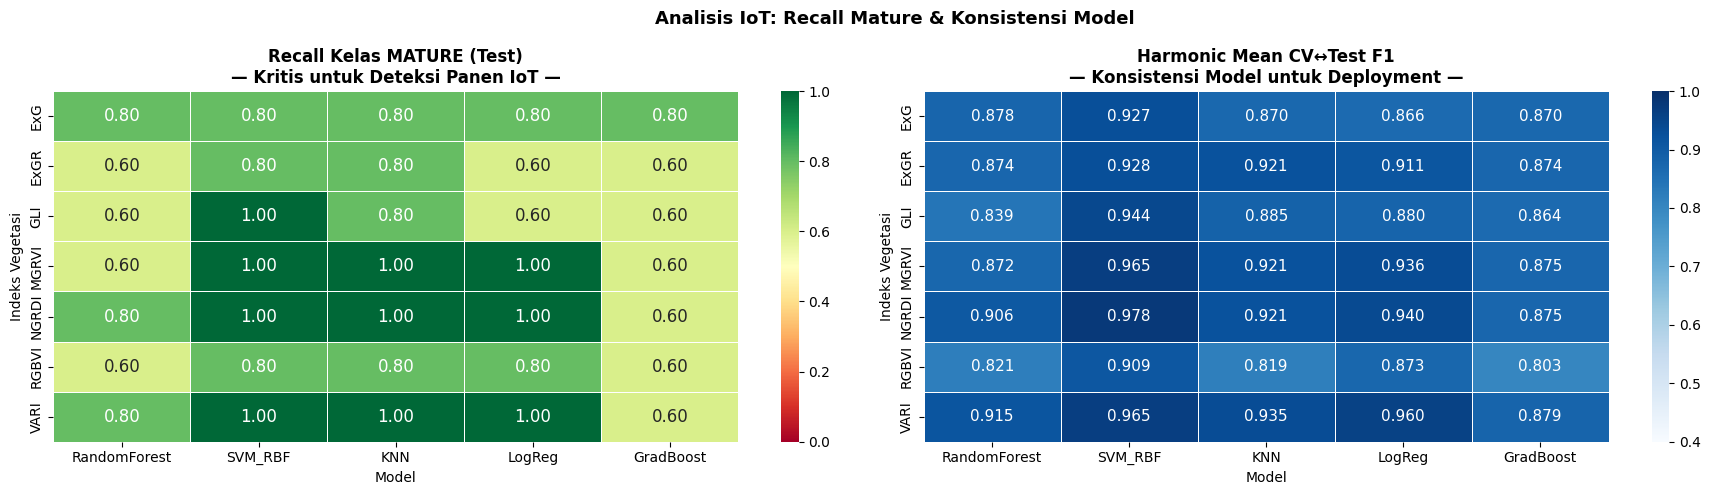


📱 Rekomendasi untuk IoT ESP32:
   VI    : NGRDI
   Model : SVM_RBF
   Recall Mature  : 1.0000  (tidak melewatkan panen)
   CV F1-Macro    : 0.9570
   Test F1-Macro  : 1.0000
   HMean CV↔Test  : 0.9780

💡 Pipeline IoT:
   ESP32-CAM → foto RGB → server → hitung NGRDI + GLCM → SVM_RBF → notifikasi


In [29]:
print("=" * 65)
print("  ANALISIS IoT — RECALL KELAS MATURE (Kritis untuk Panen)")
print("=" * 65)

mature_idx = list(le.classes_).index("Mature")

mature_recalls = []
for _, row in exp_df.iterrows():
    vi      = row["vi"]
    mod     = row["model"]
    vi_cols = [f"{vi}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_tv_i = trainval_df[vi_cols].values
    X_te_i = test_df[vi_cols].values

    ros_i = RandomOverSampler(random_state=42)
    X_si, y_si = ros_i.fit_resample(X_tv_i, y_trainval)
    clf_i = get_models()[mod]
    clf_i.fit(X_si, y_si)
    pred_i = clf_i.predict(X_te_i)

    cm_i = confusion_matrix(y_test, pred_i)
    n_mature = cm_i[mature_idx].sum()
    recall_m = float(cm_i[mature_idx, mature_idx] / n_mature) if n_mature > 0 else 0.0

    mature_recalls.append({
        "vi": vi, "model": mod,
        "recall_mature":  round(recall_m, 4),
        "cv_f1_macro":    row["cv_f1_macro"],
        "test_f1_macro":  row["test_f1_macro"],
        "cv_test_hmean":  row["cv_test_hmean"],
    })

df_mature = (pd.DataFrame(mature_recalls)
             .sort_values(["recall_mature","cv_test_hmean"], ascending=False)
             .reset_index(drop=True))
df_mature.index += 1

print("\nTop 10 — Recall Mature tertinggi (IoT harvest detection):")
display(df_mature.head(10))

# Heatmap recall Mature
pivot_rm = pd.DataFrame(mature_recalls).pivot(
    index="vi", columns="model", values="recall_mature")[MODEL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_rm, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=axes[0], vmin=0.0, vmax=1.0, annot_kws={"size": 12})
axes[0].set_title("Recall Kelas MATURE (Test)\n— Kritis untuk Deteksi Panen IoT —",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Indeks Vegetasi")

pivot_hmean = exp_df.pivot(index="vi", columns="model", values="cv_test_hmean")[MODEL_NAMES]
sns.heatmap(pivot_hmean, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, ax=axes[1], vmin=0.4, vmax=1.0, annot_kws={"size": 11})
axes[1].set_title("Harmonic Mean CV↔Test F1\n— Konsistensi Model untuk Deployment —",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Indeks Vegetasi")

plt.suptitle("Analisis IoT: Recall Mature & Konsistensi Model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Rekomendasi akhir
best_iot = df_mature.iloc[0]
print(f"\n📱 Rekomendasi untuk IoT ESP32:")
print(f"   VI    : {best_iot['vi']}")
print(f"   Model : {best_iot['model']}")
print(f"   Recall Mature  : {best_iot['recall_mature']:.4f}  (tidak melewatkan panen)")
print(f"   CV F1-Macro    : {best_iot['cv_f1_macro']:.4f}")
print(f"   Test F1-Macro  : {best_iot['test_f1_macro']:.4f}")
print(f"   HMean CV↔Test  : {best_iot['cv_test_hmean']:.4f}")
print(f"\n💡 Pipeline IoT:")
print(f"   ESP32-CAM → foto RGB → server → hitung {best_iot['vi']} + GLCM → {best_iot['model']} → notifikasi")


## 💾 Simpan Output

In [30]:
# DRIVE_DIR sudah di-set di cell 6 (auto-detect dari lokasi zip)
# Kalau cell 6 belum dijalankan, fallback ke MyDrive root
if 'DRIVE_DIR' not in dir():
    DRIVE_DIR = '/content/drive/MyDrive'
    print(f'Warning: DRIVE_DIR belum di-set, fallback ke {DRIVE_DIR}')

# Path lokal Colab
BEST_MODEL_PATH = f'/content/best_3class_{prac_vi}_{prac_model}.joblib'
ENC_PATH        = '/content/label_encoder_3class.joblib'

# Path Google Drive (bisa langsung download dari sini)
BEST_MODEL_DRIVE = f'{DRIVE_DIR}/best_3class_{prac_vi}_{prac_model}.joblib'
ENC_DRIVE        = f'{DRIVE_DIR}/label_encoder_3class.joblib'

joblib.dump(best_clf, BEST_MODEL_PATH)
joblib.dump(le,       ENC_PATH)
joblib.dump(best_clf, BEST_MODEL_DRIVE)
joblib.dump(le,       ENC_DRIVE)

print('Saved ke Colab  :', BEST_MODEL_PATH)
print('Saved ke Drive  :', BEST_MODEL_DRIVE)
print('Encoder ke Drive:', ENC_DRIVE)
print(f'CSV ke Drive    : {DRIVE_DIR}/features_3class.csv')
print(f'Nama file model : best_3class_{prac_vi}_{prac_model}.joblib')
print('Salin file .joblib dari Google Drive ke folder app.py')

Saved ke Colab  : /content/best_3class_NGRDI_SVM_RBF.joblib
Saved ke Drive  : /content/drive/MyDrive/best_3class_NGRDI_SVM_RBF.joblib
Encoder ke Drive: /content/drive/MyDrive/label_encoder_3class.joblib
CSV ke Drive    : /content/drive/MyDrive/features_3class.csv
Nama file model : best_3class_NGRDI_SVM_RBF.joblib
Salin file .joblib dari Google Drive ke folder app.py


In [31]:
from google.colab import files
files.download(EXP_CSV)
files.download(BEST_MODEL_PATH)
files.download(ENC_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🤖 Fungsi Prediksi — 3 Kelas

In [32]:
def predict_image(image_path, vi_name=None, model_clf=None, label_encoder=None):
    """
    Prediksi fase pertumbuhan padi (3 kelas: Vegetative / Generative / Mature).
    Default pakai kombinasi VI + model terbaik dari eksperimen.
    """
    if vi_name is None:      vi_name      = best_vi
    if model_clf is None:    model_clf    = best_clf
    if label_encoder is None: label_encoder = le

    rgb = read_rgb(image_path)
    if rgb is None:
        raise ValueError(f"Gagal membaca: {image_path}")

    mask   = green_mask(rgb)
    vi_fn  = VI_REGISTRY[vi_name]
    vi_map = vi_fn(rgb)
    vi_use = vi_map[mask] if mask.mean() > 0.01 else vi_map.flatten()

    stats    = extract_vi_stats(vi_use)
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    glcm     = compute_glcm_features(gray)
    vi_cols  = [f"{vi_name}_{s}" for s in STAT_NAMES] + GLCM_NAMES
    feat_vals = [stats[s] for s in STAT_NAMES] + [glcm[g] for g in GLCM_NAMES]

    X          = np.array([feat_vals], dtype=np.float32)
    pred_id    = model_clf.predict(X)[0]
    pred_label = label_encoder.inverse_transform([pred_id])[0]

    # Interpretasi untuk petani
    interpretasi = {
        "Vegetative": "🌱 Fase vegetatif — tanaman masih tumbuh, belum mendekati panen.",
        "Generative": "🌾 Fase generatif — bulir sedang berkembang, panen masih beberapa minggu.",
        "Mature":     "✅ Fase matang — padi siap dipanen!",
    }

    return {
        "prediksi":      pred_label,
        "interpretasi":  interpretasi[pred_label],
    }

# Test prediksi
example = test_df["path"].iloc[0]
result  = predict_image(example)
true    = test_df.iloc[0]["label"]

print(f"Gambar      : {os.path.basename(example)}")
print(f"True label  : {true}")
print(f"Prediksi    : {result['prediksi']}")
print(f"Keterangan  : {result['interpretasi']}")
print(f"{'✅ Benar' if result['prediksi'] == true else '❌ Salah'}")


Gambar      : DSC02101_JPG.rf.01b9a174e1f8b6f42312f0fb944df99f.jpg
True label  : Generative
Prediksi    : Vegetative
Keterangan  : 🌱 Fase vegetatif — tanaman masih tumbuh, belum mendekati panen.
❌ Salah


## Patch-Based Experiment: Semua VI x Semua Model

Mengulang eksperimen **7 VI x 5 Model** tetapi dengan fitur **patch-level**.
Setiap gambar dipecah menjadi `PATCH_GRID x PATCH_GRID` patch — tiap patch mendapat label yang sama dengan gambar induknya (*weak supervision*).

Pipeline identik dengan eksperimen whole-image di atas:
- `green_fraction` (1 fitur)
- Stats per VI (10 fitur x 7 VI = 70 fitur)
- GLCM (8 fitur)
- **Total: 79 fitur per patch**

Hasil terbaik disimpan sebagai `best_patch_{VI}_{MODEL}.joblib`.

In [33]:
PATCH_GRID = 3  # NxN — ubah ke 4 untuk granularitas lebih tinggi

PATCH_CSV       = "/content/patch_features.csv"
PATCH_CSV_DRIVE = f"{DRIVE_DIR}/patch_features.csv"

print(f"Grid patch : {PATCH_GRID}x{PATCH_GRID} = {PATCH_GRID**2} patch/gambar")
print(f"Estimasi total patch: {PATCH_GRID**2} x (jumlah gambar)")

Grid patch : 3x3 = 9 patch/gambar
Estimasi total patch: 9 x (jumlah gambar)


In [34]:
# Ekstraksi fitur patch untuk SEMUA VI sekaligus (1 pass per gambar)
from collections import Counter

patch_rows = []
fail_count_patch = 0

for split in ["train", "valid", "test"]:
    for cls in CLASS_ORDER:
        folder = os.path.join(DATA_ROOT, split, cls)
        if not os.path.exists(folder):
            continue
        img_paths = []
        for ext in IMAGE_EXTS:
            img_paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))

        for img_path in tqdm(img_paths, desc=f"{split}/{cls}", leave=False):
            rgb = read_rgb(img_path)
            if rgb is None:
                fail_count_patch += 1
                continue

            h, w   = rgb.shape[:2]
            ph, pw = h // PATCH_GRID, w // PATCH_GRID

            for r in range(PATCH_GRID):
                for c in range(PATCH_GRID):
                    patch = rgb[r*ph:(r+1)*ph, c*pw:(c+1)*pw]
                    if patch.size == 0:
                        continue
                    try:
                        mask      = green_mask(patch)
                        gray      = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
                        glcm_feat = compute_glcm_features(gray)

                        row = {
                            "label":          cls,
                            "split":          split,
                            "green_fraction": float(mask.mean()),
                        }
                        for vi_name, vi_fn in VI_REGISTRY.items():
                            vi_map = vi_fn(patch)
                            stats  = extract_vi_stats(vi_map.flatten())
                            for k, v in stats.items():
                                row[f"{vi_name}_{k}"] = v
                        row.update(glcm_feat)
                        patch_rows.append(row)
                    except Exception:
                        continue

df_patch = pd.DataFrame(patch_rows)
df_patch["y"] = le.transform(df_patch["label"])

print(f"Total patch : {len(df_patch):,}")
print(f"Fitur       : {df_patch.shape[1]} kolom")
print(f"Distribusi split: {dict(Counter(df_patch['split']))}")
print(f"Distribusi kelas: {dict(Counter(df_patch['label']))}")
if fail_count_patch:
    print(f"Gambar gagal: {fail_count_patch}")

Total patch : 5,148
Fitur       : 82 kolom
Distribusi split: {'train': 4509, 'valid': 324, 'test': 315}
Distribusi kelas: {'Vegetative': 3168, 'Generative': 1386, 'Mature': 594}


In [35]:
df_patch.to_csv(PATCH_CSV, index=False)
df_patch.to_csv(PATCH_CSV_DRIVE, index=False)
print(f"Patch features disimpan: {PATCH_CSV}")
print(f"Backup Drive           : {PATCH_CSV_DRIVE}")

Patch features disimpan: /content/patch_features.csv
Backup Drive           : /content/drive/MyDrive/patch_features.csv


In [36]:
patch_trainval = df_patch[df_patch["split"].isin(["train", "valid"])].copy()
patch_test     = df_patch[df_patch["split"] == "test"].copy()

y_patch_trainval = patch_trainval["y"].values
y_patch_test     = patch_test["y"].values

print(f"TrainVal patch: {len(patch_trainval):,}")
print(f"Test patch    : {len(patch_test):,}")
print(f"Kelas trainval: {dict(Counter(le.inverse_transform(y_patch_trainval)))}")
print(f"Kelas test    : {dict(Counter(le.inverse_transform(y_patch_test)))}")

TrainVal patch: 4,833
Test patch    : 315
Kelas trainval: {np.str_('Vegetative'): 2970, np.str_('Generative'): 1314, np.str_('Mature'): 549}
Kelas test    : {np.str_('Vegetative'): 198, np.str_('Generative'): 72, np.str_('Mature'): 45}


### Resampling Patch Dataset

Dataset patch tidak seimbang: Vegetative jauh lebih banyak dari Mature.
Strategi: **undersample Vegetative + Generative** ke batas tertentu, lalu **oversample Mature** ke jumlah yang sama.

Resampling hanya dilakukan pada **trainval** — test set tetap data asli.

In [37]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

# Distribusi sebelum resampling
before = Counter(le.inverse_transform(y_patch_trainval))
print('Distribusi SEBELUM resampling:')
for k, v in before.items(): print(f'  {k:12s}: {v:,}')

# Target jumlah per kelas:
#   Mature    → tetap (kelas terkecil, jadikan acuan)
#   Generative → undersample ke max 2x Mature
#   Vegetative → undersample ke max 2x Mature
n_mature     = before.get('Mature', 1)
target_max   = n_mature * 2  # batas atas untuk kelas besar

# Pakai kolom dummy untuk resampling — ambil 1 VI saja sebagai proxy
# (resampling hanya tentukan index yang dipakai, bukan fiturnya)
_proxy_cols = [f"{VI_NAMES[0]}_{s}" for s in STAT_NAMES] + GLCM_NAMES
_X_proxy    = patch_trainval[_proxy_cols].values

# Step 1: Undersample kelas besar ke target_max
under_strategy = {
    le.transform(['Vegetative'])[0]: min(before.get('Vegetative', 0), target_max),
    le.transform(['Generative'])[0]: min(before.get('Generative', 0), target_max),
    le.transform(['Mature'])[0]:     before.get('Mature', 0),
}
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
_X_under, _y_under = rus.fit_resample(_X_proxy, y_patch_trainval)

# Step 2: Oversample Mature ke target_max
over_strategy = {
    le.transform(['Mature'])[0]: target_max,
}
ros = RandomOverSampler(sampling_strategy=over_strategy, random_state=42)
_X_bal, _y_bal = ros.fit_resample(_X_under, _y_under)

# Terapkan index hasil resampling ke df_patch
# Under: ambil baris sesuai index dari RandomUnderSampler
under_idx         = rus.sample_indices_
patch_trainval_rs = patch_trainval.iloc[under_idx].copy().reset_index(drop=True)
y_patch_tv_rs     = y_patch_trainval[under_idx]

# Over: duplikat baris Mature sesuai index RandomOverSampler
# (ros.sample_indices_ sudah include duplikat)
over_idx          = ros.sample_indices_
patch_trainval_rs = patch_trainval_rs.iloc[over_idx].copy().reset_index(drop=True)
y_patch_tv_rs     = y_patch_tv_rs[over_idx]

after = Counter(le.inverse_transform(y_patch_tv_rs))
print(f'\nDistribusi SESUDAH resampling (target_max={target_max:,}):')
for k, v in after.items(): print(f'  {k:12s}: {v:,}')
print(f'\nTotal trainval patch: {len(patch_trainval_rs):,} (dari {len(patch_trainval):,})')

Distribusi SEBELUM resampling:
  Vegetative  : 2,970
  Generative  : 1,314
  Mature      : 549

Distribusi SESUDAH resampling (target_max=1,098):
  Generative  : 1,098
  Mature      : 1,098
  Vegetative  : 1,098

Total trainval patch: 3,294 (dari 4,833)


In [38]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import StratifiedKFold, cross_validate

skf_patch     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
patch_results = []

for vi_name in VI_NAMES:
    vi_feat_cols = [f"{vi_name}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_tv = patch_trainval_rs[vi_feat_cols].values
    X_te = patch_test[vi_feat_cols].values

    print(f"\n{'='*52}")
    print(f"  VI: {vi_name}  ({len(vi_feat_cols)} fitur)  | patch-level")
    print(f"{'='*52}")

    for model_name, pipe_cv in get_models_with_ros().items():
        # CV dengan ROS di dalam pipeline (tidak ada data leakage)
        cv_scores = cross_validate(
            pipe_cv, X_tv, y_patch_tv_rs, cv=skf_patch,
            scoring=["accuracy", "f1_macro", "f1_weighted"], n_jobs=-1
        )
        cv_acc  = float(cv_scores["test_accuracy"].mean())
        cv_f1m  = float(cv_scores["test_f1_macro"].mean())
        cv_f1w  = float(cv_scores["test_f1_weighted"].mean())
        cv_std  = float(cv_scores["test_f1_macro"].std())

        # Latih pada seluruh trainval, evaluasi test
        plain_model = get_models()[model_name]
        plain_model.fit(X_tv, y_patch_tv_rs)
        y_te_pred   = plain_model.predict(X_te)
        test_f1m    = float(f1_score(y_patch_test, y_te_pred, average="macro"))
        test_acc    = float(accuracy_score(y_patch_test, y_te_pred))

        patch_results.append({
            "vi": vi_name, "model": model_name,
            "cv_f1_macro": cv_f1m, "cv_f1_std": cv_std,
            "cv_accuracy": cv_acc, "cv_f1_weighted": cv_f1w,
            "test_f1": test_f1m, "test_accuracy": test_acc,
            "test_f1_macro": test_f1m,
        })
        print(f"  {model_name:<14s} CV={cv_f1m:.4f}±{cv_std:.4f}  Test={test_f1m:.4f}")

patch_exp_df = pd.DataFrame(patch_results)
print(f"\nEksperimen selesai: {len(patch_exp_df)} kombinasi")


  VI: VARI  (18 fitur)  | patch-level
  RandomForest   CV=0.9323±0.0093  Test=0.8605
  SVM_RBF        CV=0.9336±0.0119  Test=0.8880
  KNN            CV=0.9074±0.0127  Test=0.8520
  LogReg         CV=0.9038±0.0138  Test=0.8373
  GradBoost      CV=0.9340±0.0087  Test=0.8679

  VI: ExG  (18 fitur)  | patch-level
  RandomForest   CV=0.9290±0.0112  Test=0.8199
  SVM_RBF        CV=0.9310±0.0073  Test=0.8330
  KNN            CV=0.8879±0.0122  Test=0.8087
  LogReg         CV=0.8870±0.0122  Test=0.7557
  GradBoost      CV=0.9299±0.0101  Test=0.8423

  VI: ExGR  (18 fitur)  | patch-level
  RandomForest   CV=0.9596±0.0044  Test=0.8422
  SVM_RBF        CV=0.9600±0.0039  Test=0.8959
  KNN            CV=0.9490±0.0097  Test=0.8684
  LogReg         CV=0.9482±0.0095  Test=0.8491
  GradBoost      CV=0.9588±0.0093  Test=0.8526

  VI: GLI  (18 fitur)  | patch-level
  RandomForest   CV=0.9181±0.0083  Test=0.8130
  SVM_RBF        CV=0.9349±0.0063  Test=0.8582
  KNN            CV=0.8778±0.0023  Test=0.8315


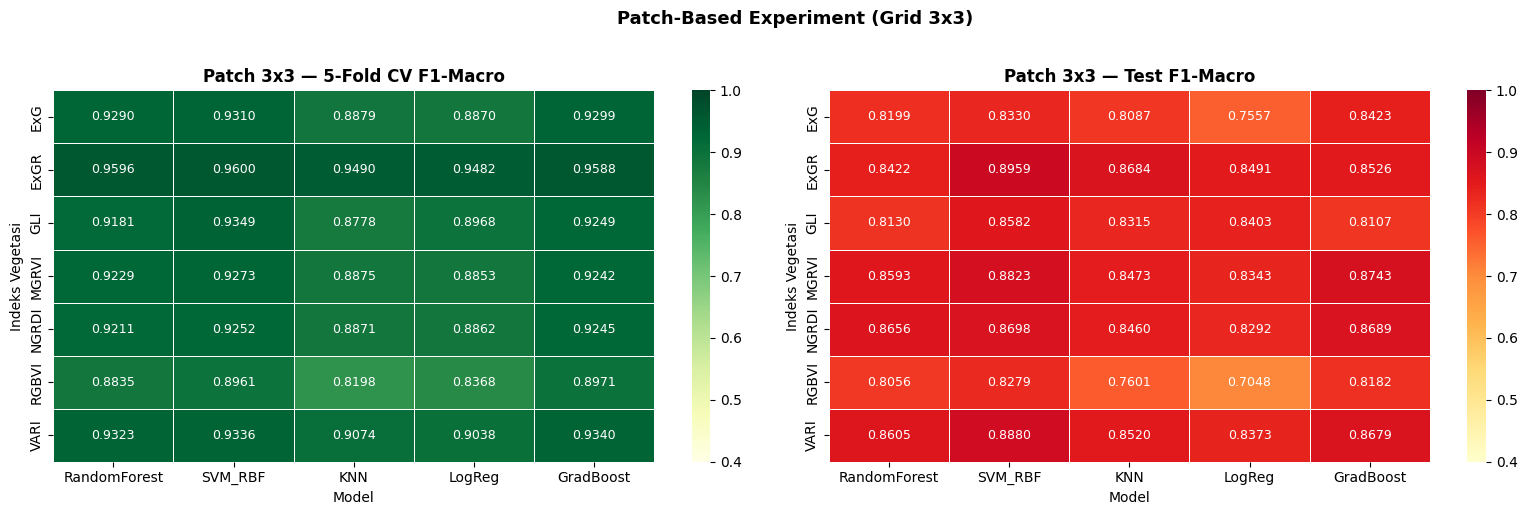

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_cv   = patch_exp_df.pivot(index="vi", columns="model", values="cv_f1_macro")[MODEL_NAMES]
pivot_test = patch_exp_df.pivot(index="vi", columns="model", values="test_f1_macro")[MODEL_NAMES]

sns.heatmap(pivot_cv, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, ax=axes[0], vmin=0.4, vmax=1.0, annot_kws={"size": 9})
axes[0].set_title(f"Patch {PATCH_GRID}x{PATCH_GRID} — 5-Fold CV F1-Macro",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Indeks Vegetasi")

sns.heatmap(pivot_test, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], vmin=0.4, vmax=1.0, annot_kws={"size": 9})
axes[1].set_title(f"Patch {PATCH_GRID}x{PATCH_GRID} — Test F1-Macro",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Indeks Vegetasi")

plt.suptitle(f"Patch-Based Experiment (Grid {PATCH_GRID}x{PATCH_GRID})",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"/content/patch_heatmap_{PATCH_GRID}x{PATCH_GRID}.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# Urutkan: CV F1-Macro tinggi, std rendah, gap CV-Test kecil
patch_exp_df["gap"]       = abs(patch_exp_df["cv_f1_macro"] - patch_exp_df["test_f1_macro"])
patch_exp_df["practical"] = patch_exp_df["cv_f1_macro"] - patch_exp_df["cv_f1_std"] - patch_exp_df["gap"]

best_patch_row    = patch_exp_df.sort_values("cv_f1_macro", ascending=False).iloc[0]
prac_patch_row    = patch_exp_df.sort_values("practical",   ascending=False).iloc[0]

best_patch_vi     = best_patch_row["vi"]
best_patch_model  = best_patch_row["model"]
prac_patch_vi     = prac_patch_row["vi"]
prac_patch_model  = prac_patch_row["model"]

print("=" * 62)
print("  HASIL PATCH EXPERIMENT")
print("=" * 62)
print(f"  Terbaik (CV F1)  : {best_patch_vi} + {best_patch_model}")
print(f"    CV  F1-Macro   : {best_patch_row['cv_f1_macro']:.4f} +/- {best_patch_row['cv_f1_std']:.4f}")
print(f"    Test F1-Macro  : {best_patch_row['test_f1_macro']:.4f}")
print()
print(f"  Praktis (stabil) : {prac_patch_vi} + {prac_patch_model}")
print(f"    CV  F1-Macro   : {prac_patch_row['cv_f1_macro']:.4f} +/- {prac_patch_row['cv_f1_std']:.4f}")
print(f"    Test F1-Macro  : {prac_patch_row['test_f1_macro']:.4f}")
print("=" * 62)

# Bandingkan dengan whole-image
whole_row  = exp_df[(exp_df['vi'] == prac_vi) & (exp_df['model'] == prac_model)].iloc[0]
patch_row_ = prac_patch_row
delta_cv   = patch_row_['cv_f1_macro'] - whole_row['cv_f1_macro']
delta_test = patch_row_['test_f1_macro'] - whole_row['test_f1_macro']

print()
print("  Perbandingan Whole-Image vs Patch (rekomendasi praktis):")
print(f"    {'':30s} {'CV F1':>8s}  {'Test F1':>8s}")
print(f"    {'Whole-image ('+prac_vi+'+'+prac_model+')':30s} {whole_row['cv_f1_macro']:>8.4f}  {whole_row['test_f1_macro']:>8.4f}")
print(f"    {'Patch ('+prac_patch_vi+'+'+prac_patch_model+')':30s} {patch_row_['cv_f1_macro']:>8.4f}  {patch_row_['test_f1_macro']:>8.4f}")
sign_cv   = '+' if delta_cv   >= 0 else ''
sign_test = '+' if delta_test >= 0 else ''
print(f"    {'Delta':30s} {sign_cv+f'{delta_cv:.4f}':>8s}  {sign_test+f'{delta_test:.4f}':>8s}")

  HASIL PATCH EXPERIMENT
  Terbaik (CV F1)  : ExGR + SVM_RBF
    CV  F1-Macro   : 0.9600 +/- 0.0039
    Test F1-Macro  : 0.8959

  Praktis (stabil) : ExGR + SVM_RBF
    CV  F1-Macro   : 0.9600 +/- 0.0039
    Test F1-Macro  : 0.8959

  Perbandingan Whole-Image vs Patch (rekomendasi praktis):
                                      CV F1   Test F1
    Whole-image (NGRDI+SVM_RBF)      0.9570    1.0000
    Patch (ExGR+SVM_RBF)             0.9600    0.8959
    Delta                           +0.0030   -0.1041


In [41]:
# Latih ulang model patch terbaik pada seluruh trainval
FINAL_PATCH_VI    = prac_patch_vi
FINAL_PATCH_MODEL = prac_patch_model

vi_feat_cols_patch = [f"{FINAL_PATCH_VI}_{s}" for s in STAT_NAMES] + GLCM_NAMES

X_tv_final = patch_trainval[vi_feat_cols_patch].values
X_te_final = patch_test[vi_feat_cols_patch].values

best_patch_clf = get_models()[FINAL_PATCH_MODEL]
best_patch_clf.fit(X_tv_final, y_patch_trainval)

y_final_pred   = best_patch_clf.predict(X_te_final)
print("Classification Report — Best Patch Model (test set):")
print(classification_report(y_patch_test, y_final_pred, target_names=le.classes_))

print(f"Model: {FINAL_PATCH_VI} + {FINAL_PATCH_MODEL}  |  Grid: {PATCH_GRID}x{PATCH_GRID}")

Classification Report — Best Patch Model (test set):
              precision    recall  f1-score   support

  Generative       0.88      0.78      0.82        72
      Mature       0.84      0.84      0.84        45
  Vegetative       0.95      0.99      0.97       198

    accuracy                           0.92       315
   macro avg       0.89      0.87      0.88       315
weighted avg       0.92      0.92      0.92       315

Model: ExGR + SVM_RBF  |  Grid: 3x3


In [42]:
PATCH_MODEL_PATH  = f"/content/best_patch_{FINAL_PATCH_VI}_{FINAL_PATCH_MODEL}.joblib"
PATCH_ENC_PATH    = "/content/label_encoder_patch.joblib"
PATCH_MODEL_DRIVE = f"{DRIVE_DIR}/best_patch_{FINAL_PATCH_VI}_{FINAL_PATCH_MODEL}.joblib"
PATCH_ENC_DRIVE   = f"{DRIVE_DIR}/label_encoder_patch.joblib"

joblib.dump(best_patch_clf, PATCH_MODEL_PATH)
joblib.dump(le,             PATCH_ENC_PATH)
joblib.dump(best_patch_clf, PATCH_MODEL_DRIVE)
joblib.dump(le,             PATCH_ENC_DRIVE)

print("Model patch terbaik disimpan:")
print(f"  Lokal : {PATCH_MODEL_PATH}")
print(f"  Lokal : {PATCH_ENC_PATH}")
print(f"  Drive : {PATCH_MODEL_DRIVE}")
print(f"  Drive : {PATCH_ENC_DRIVE}")
print()
print("Nama file yang digunakan app.py:")
print(f"  best_patch_{FINAL_PATCH_VI}_{FINAL_PATCH_MODEL}.joblib")
print(f"  label_encoder_patch.joblib")

from google.colab import files
files.download(PATCH_MODEL_PATH)
files.download(PATCH_ENC_PATH)

Model patch terbaik disimpan:
  Lokal : /content/best_patch_ExGR_SVM_RBF.joblib
  Lokal : /content/label_encoder_patch.joblib
  Drive : /content/drive/MyDrive/best_patch_ExGR_SVM_RBF.joblib
  Drive : /content/drive/MyDrive/label_encoder_patch.joblib

Nama file yang digunakan app.py:
  best_patch_ExGR_SVM_RBF.joblib
  label_encoder_patch.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Deep Learning — CNN Transfer Learning

Pendekatan alternatif: pakai **CNN (Convolutional Neural Network)** dengan transfer learning dari EfficientNetB0 yang sudah pretrained di ImageNet. CNN bisa belajar fitur spasial seperti bentuk malai menunduk — yang tidak bisa ditangkap SVM + VI.

**Strategi mengatasi imbalance** (Vegetative 558 vs Mature 101):
1. **Class weight** di loss function — kelas minoritas dapat bobot lebih besar
2. **Augmentasi agresif** — flip, rotasi, zoom, brightness untuk semua kelas
3. **Two-phase training** — freeze base → fine-tune top layers

**Tidak pakai CV** karena CNN training mahal (1 epoch bisa 1-2 menit) — gunakan train/valid split standar dengan EarlyStopping.

In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', len(gpus) > 0, gpus if gpus else '(akan training di CPU - lambat!)')

# Config CNN
IMG_SIZE   = 224       # EfficientNetB0 input
BATCH_SIZE = 16
EPOCHS_HEAD     = 10   # Phase 1: train head saja
EPOCHS_FINETUNE = 15   # Phase 2: fine-tune top layers

print(f'\nConfig: img={IMG_SIZE}, batch={BATCH_SIZE}, classes={CLASS_ORDER}')

TensorFlow version: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Config: img=224, batch=16, classes=['Vegetative', 'Generative', 'Mature']


In [44]:
# Augmentasi agresif di train untuk kompensasi data sedikit
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='reflect',
)

# Valid & test: TANPA augmentasi, hanya preprocess
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATA_ROOT, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=CLASS_ORDER,
    class_mode='categorical',
    shuffle=True,
    seed=42,
)

valid_generator = eval_datagen.flow_from_directory(
    os.path.join(DATA_ROOT, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=CLASS_ORDER,
    class_mode='categorical',
    shuffle=False,
)

test_generator = eval_datagen.flow_from_directory(
    os.path.join(DATA_ROOT, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=CLASS_ORDER,
    class_mode='categorical',
    shuffle=False,
)

print(f'\nClass indices: {train_generator.class_indices}')
print(f'Train: {train_generator.samples} | Valid: {valid_generator.samples} | Test: {test_generator.samples}')

Found 501 images belonging to 3 classes.
Found 36 images belonging to 3 classes.
Found 35 images belonging to 3 classes.

Class indices: {'Vegetative': 0, 'Generative': 1, 'Mature': 2}
Train: 501 | Valid: 36 | Test: 35


In [45]:
# Hitung class weight: kelas minoritas dapat bobot lebih besar
y_train_int = train_generator.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}

print('Class weights (semakin besar = kelas lebih diperhatikan loss):')
for idx, cls in enumerate(CLASS_ORDER):
    n_samples = int(np.sum(y_train_int == idx))
    print(f'  {cls:12s} (n={n_samples:>3d})  weight = {class_weight_dict[idx]:.3f}')

Class weights (semakin besar = kelas lebih diperhatikan loss):
  Vegetative   (n=306)  weight = 0.546
  Generative   (n=138)  weight = 1.210
  Mature       (n= 57)  weight = 2.930


In [46]:
def build_cnn_model(n_classes=3, dropout=0.3):
    """EfficientNetB0 (ImageNet pretrained) + custom classification head."""
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False  # Freeze dulu untuk phase 1

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(dropout)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(dropout)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

cnn_model, base_model = build_cnn_model(n_classes=len(CLASS_ORDER))
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print(f'Total params       : {cnn_model.count_params():,}')
print(f'Trainable params   : {sum(np.prod(v.shape) for v in cnn_model.trainable_weights):,}')
print(f'Frozen base layers : {len(base_model.layers)}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params       : 4,213,926
Trainable params   : 164,355
Frozen base layers : 238


In [47]:
# Phase 1: latih head saja (base di-freeze)
callbacks_phase1 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

print('=' * 55)
print('  PHASE 1: Train classification head (base frozen)')
print('=' * 55)

history1 = cnn_model.fit(
    train_generator,
    epochs=EPOCHS_HEAD,
    validation_data=valid_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1,
)

  PHASE 1: Train classification head (base frozen)
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7984 - loss: 0.6158 - val_accuracy: 0.8889 - val_loss: 0.1630 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.9182 - loss: 0.2776 - val_accuracy: 0.9444 - val_loss: 0.0872 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 319ms/step - accuracy: 0.9361 - loss: 0.2116 - val_accuracy: 0.9444 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step - accuracy: 0.9501 - loss: 0.1685 - val_accuracy: 1.0000 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.9561 - loss: 0.1388 - val_accuracy: 0.9722 - val_loss: 0.0542 - learning_rate: 0.0010
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.9661 - loss: 0.1510 - val_accuracy: 0.9444 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━

In [48]:
# Phase 2: unfreeze top 30 layer base + fine-tune dengan LR kecil
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile dengan LR jauh lebih kecil (jangan hancurkan pretrained weights)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        '/content/best_cnn_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1,
    ),
]

print('=' * 55)
print('  PHASE 2: Fine-tune top 30 layers (LR=1e-5)')
print('=' * 55)
trainable_count = sum(np.prod(v.shape) for v in cnn_model.trainable_weights)
print(f'Trainable params now: {int(trainable_count):,}')

history2 = cnn_model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=valid_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1,
)

  PHASE 2: Fine-tune top 30 layers (LR=1e-5)
Trainable params now: 1,660,515
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.7895 - loss: 0.4591
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/best_cnn_model.keras

Epoch 1: finished saving model to /content/best_cnn_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8004 - loss: 0.4350 - val_accuracy: 1.0000 - val_loss: 0.0200 - learning_rate: 1.0000e-05
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8356 - loss: 0.4087
Epoch 2: val_accuracy did not improve from 1.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 276ms/step - accuracy: 0.8244 - loss: 0.4268 - val_accuracy: 1.0000 - val_loss: 0.0219 - learning_rate: 1.0000e-05
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8338 - loss: 0.4284
Epoch 3: val_accuracy did not improve from 1.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 320ms/step - accuracy: 0.8244 - loss: 0.3909 - val_accuracy: 1.0000 - val_loss: 

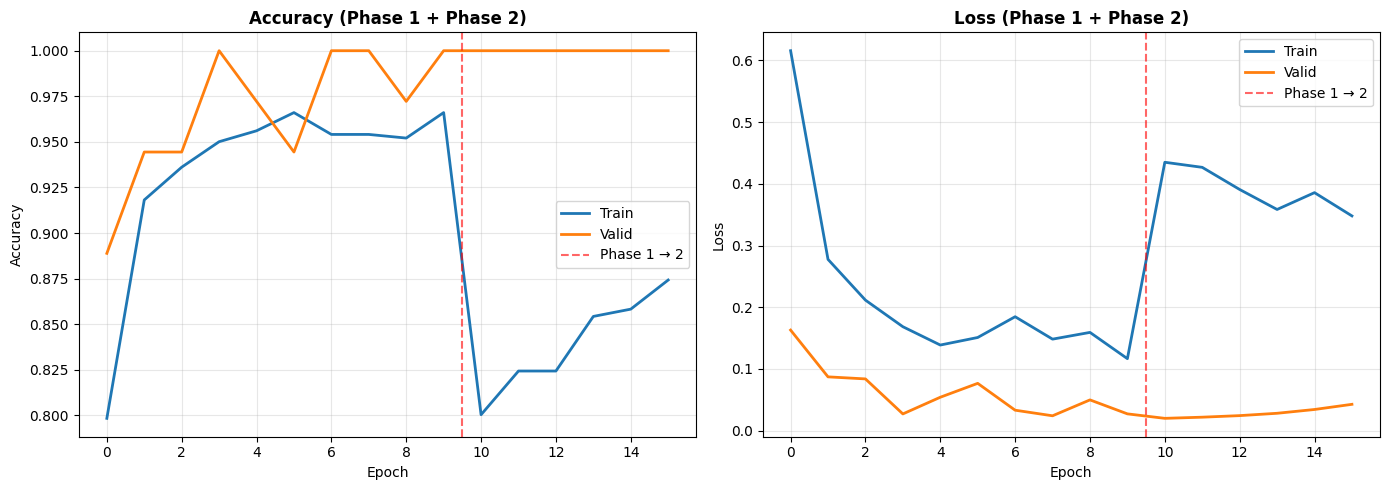

In [49]:
# Gabungkan history phase 1 + phase 2
def merge_hist(h1, h2, key):
    return list(h1.history.get(key, [])) + list(h2.history.get(key, []))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(merge_hist(history1, history2, 'accuracy'),     label='Train', linewidth=2)
axes[0].plot(merge_hist(history1, history2, 'val_accuracy'), label='Valid', linewidth=2)
axes[0].axvline(x=len(history1.history['accuracy'])-0.5, color='red', linestyle='--',
                alpha=0.6, label='Phase 1 → 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy (Phase 1 + Phase 2)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(merge_hist(history1, history2, 'loss'),     label='Train', linewidth=2)
axes[1].plot(merge_hist(history1, history2, 'val_loss'), label='Valid', linewidth=2)
axes[1].axvline(x=len(history1.history['loss'])-0.5, color='red', linestyle='--',
                alpha=0.6, label='Phase 1 → 2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss (Phase 1 + Phase 2)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/cnn_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

Evaluating CNN on test set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step

Test Accuracy : 0.9429
Test F1-Macro : 0.8917

Classification Report:
              precision    recall  f1-score   support

  Vegetative       1.00      1.00      1.00        22
  Generative       0.88      0.88      0.88         8
      Mature       0.80      0.80      0.80         5

    accuracy                           0.94        35
   macro avg       0.89      0.89      0.89        35
weighted avg       0.94      0.94      0.94        35



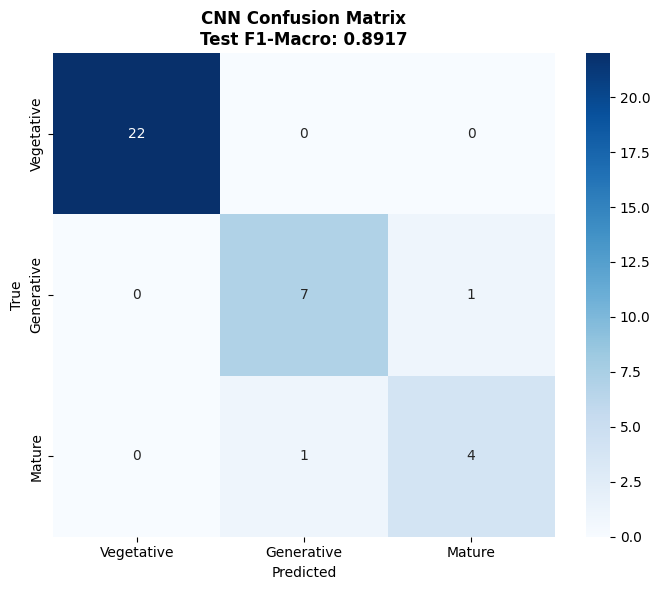

In [50]:
# Evaluasi CNN pada test set
print('Evaluating CNN on test set...')
test_generator.reset()
y_pred_proba = cnn_model.predict(test_generator, verbose=1)
y_pred_cnn   = np.argmax(y_pred_proba, axis=1)
y_true_cnn   = test_generator.classes

test_acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
test_f1_cnn  = f1_score(y_true_cnn, y_pred_cnn, average='macro')

print(f'\nTest Accuracy : {test_acc_cnn:.4f}')
print(f'Test F1-Macro : {test_f1_cnn:.4f}\n')

print('Classification Report:')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASS_ORDER))

# Confusion matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'CNN Confusion Matrix\nTest F1-Macro: {test_f1_cnn:.4f}', fontweight='bold')
plt.tight_layout(); plt.show()

In [51]:
# Perbandingan model whole-image: SVM vs CNN
row_svm = exp_df[(exp_df['vi'] == prac_vi) & (exp_df['model'] == prac_model)].iloc[0]

print('=' * 62)
print('  PERBANDINGAN: SVM (whole-image) vs CNN (EfficientNetB0)')
print('=' * 62)
print(f"{'Model':<35s} {'Test Acc':>10s} {'Test F1':>10s}")
print('-' * 62)
print(f"  SVM ({prac_vi} + {prac_model})".ljust(35) +
      f"{row_svm['test_acc']:>10.4f} {row_svm['test_f1_macro']:>10.4f}")
print(f"  CNN (EfficientNetB0 transfer)".ljust(35) +
      f"{test_acc_cnn:>10.4f} {test_f1_cnn:>10.4f}")
print('-' * 62)
delta_acc = test_acc_cnn - row_svm['test_acc']
delta_f1  = test_f1_cnn  - row_svm['test_f1_macro']
sign_a = '+' if delta_acc >= 0 else ''
sign_f = '+' if delta_f1  >= 0 else ''
print(f"  Delta (CNN - SVM)".ljust(35) +
      f"{sign_a+f'{delta_acc:.4f}':>10s} {sign_f+f'{delta_f1:.4f}':>10s}")
print('=' * 62)

  PERBANDINGAN: SVM (whole-image) vs CNN (EfficientNetB0)
Model                                 Test Acc    Test F1
--------------------------------------------------------------
  SVM (NGRDI + SVM_RBF)                1.0000     1.0000
  CNN (EfficientNetB0 transfer)        0.9429     0.8917
--------------------------------------------------------------
  Delta (CNN - SVM)                   -0.0571    -0.1083


In [52]:
# Simpan model CNN ke Drive
CNN_MODEL_PATH  = '/content/best_cnn_efficientnetb0.keras'
CNN_MODEL_DRIVE = f'{DRIVE_DIR}/best_cnn_efficientnetb0.keras'
CNN_CLASSES_TXT = f'{DRIVE_DIR}/cnn_classes.txt'

cnn_model.save(CNN_MODEL_PATH)
cnn_model.save(CNN_MODEL_DRIVE)
with open(CNN_CLASSES_TXT, 'w') as f:
    f.write('\n'.join(CLASS_ORDER))

print('Model CNN disimpan:')
print(f'  Lokal : {CNN_MODEL_PATH}')
print(f'  Drive : {CNN_MODEL_DRIVE}')
print(f'  Classes: {CNN_CLASSES_TXT}')

from google.colab import files
files.download(CNN_MODEL_PATH)

Model CNN disimpan:
  Lokal : /content/best_cnn_efficientnetb0.keras
  Drive : /content/drive/MyDrive/best_cnn_efficientnetb0.keras
  Classes: /content/drive/MyDrive/cnn_classes.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
def predict_image_cnn(image_path, model=None, class_order=None):
    """Prediksi fase pertumbuhan padi pakai CNN."""
    if model       is None: model       = cnn_model
    if class_order is None: class_order = CLASS_ORDER

    img = keras.preprocessing.image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = keras.preprocessing.image.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    proba   = model.predict(arr, verbose=0)[0]
    pred_id = int(np.argmax(proba))
    pred    = class_order[pred_id]

    print(f'Gambar    : {os.path.basename(image_path)}')
    print(f'Prediksi  : {pred}')
    print(f'Confidence: {proba[pred_id]*100:.2f}%')
    print(f'Distribusi:')
    for cls, p in zip(class_order, proba):
        bar = '#' * int(p * 30)
        print(f'  {cls:12s} {p*100:5.2f}%  {bar}')
    return pred, dict(zip(class_order, proba.tolist()))

# Test dengan 1 gambar dari test set
test_files = test_generator.filepaths
if test_files:
    sample = test_files[0]
    predict_image_cnn(sample)

Gambar    : 00771_JPG.rf.9f6d8e4ec48480d88e91e40e70c30140.jpg
Prediksi  : Vegetative
Confidence: 100.00%
Distribusi:
  Vegetative   100.00%  #############################
  Generative    0.00%  
  Mature        0.00%  


## Hybrid CNN + VI — Eksperimen 7 VI dengan Resampled Data

Strategi gabungan: **CNN (fitur spasial) + VI (signal vegetasi) + balanced training**.

**Motivasi:**
1. CNN murni mencapai F1 0.88 tapi Mature recall hanya 60% — akibat imbalance & kurangnya signal vegetasi spesifik.
2. Resampling training: Vegetative 300 (under), Generative 245, Mature 300 (over) — rasio ~1.2 : 1 : 1.2.
3. Hybrid arsitektur: EfficientNetB0 (RGB) + 18 fitur VI → Concat → Classifier.
4. Eksperimen **7 VI**: train hybrid satu-satu untuk tiap VI, bandingkan F1 & Mature recall.

**Output**: tabel 4 model untuk dibandingkan di skripsi → SVM | CNN | Hybrid CNN+VI | LLM.

In [54]:
import shutil, random
from pathlib import Path

BALANCED_ROOT = '/content/padi_balanced'
TARGET_COUNTS = {'Vegetative': 300, 'Generative': 245, 'Mature': 300}
RNG_SEED      = 42

# Bersihkan kalau sudah ada
if os.path.exists(BALANCED_ROOT):
    shutil.rmtree(BALANCED_ROOT)

# Hanya resample TRAIN — valid & test pakai data asli
random.seed(RNG_SEED)
balanced_train = os.path.join(BALANCED_ROOT, 'train')
os.makedirs(balanced_train, exist_ok=True)

for cls in CLASS_ORDER:
    src_dir = os.path.join(DATA_ROOT, 'train', cls)
    dst_dir = os.path.join(balanced_train, cls)
    os.makedirs(dst_dir, exist_ok=True)

    src_files = []
    for ext in IMAGE_EXTS:
        src_files.extend(glob.glob(os.path.join(src_dir, f'*{ext}')))

    target = TARGET_COUNTS[cls]
    n_src  = len(src_files)

    if n_src >= target:
        # Undersample: ambil random `target` file
        chosen = random.sample(src_files, target)
        for src in chosen:
            shutil.copy(src, dst_dir)
    else:
        # Oversample: copy semua + duplikat sisanya
        for src in src_files:
            shutil.copy(src, dst_dir)
        n_extra = target - n_src
        for i in range(n_extra):
            src  = random.choice(src_files)
            base = os.path.basename(src)
            stem, ext = os.path.splitext(base)
            dst  = os.path.join(dst_dir, f'{stem}_dup{i+1}{ext}')
            shutil.copy(src, dst)

    final_count = len(os.listdir(dst_dir))
    print(f'  {cls:12s}: src={n_src:>3d} → balanced={final_count:>3d}')

total = sum(len(os.listdir(os.path.join(balanced_train, c))) for c in CLASS_ORDER)
print(f'\nTotal training images (balanced): {total}')

  Vegetative  : src=306 → balanced=300
  Generative  : src=138 → balanced=245
  Mature      : src= 57 → balanced=300

Total training images (balanced): 845


In [55]:
def extract_vi_features_for_image(image_path, vi_name):
    """Ekstrak 18 fitur: 10 stats VI + 8 GLCM dari satu gambar."""
    rgb = read_rgb(image_path)
    if rgb is None:
        return None

    vi_map = VI_REGISTRY[vi_name](rgb)
    stats  = extract_vi_stats(vi_map.flatten())
    gray   = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    glcm   = compute_glcm_features(gray)

    feats = [stats[s] for s in STAT_NAMES] + [glcm[g] for g in GLCM_NAMES]
    return np.array(feats, dtype=np.float32)

# Kumpulkan semua path: balanced train + valid + test (valid/test pakai DATA_ROOT asli)
all_image_paths = []
for split_root, split_name in [(balanced_train, 'train'),
                                (os.path.join(DATA_ROOT, 'valid'), 'valid'),
                                (os.path.join(DATA_ROOT, 'test'),  'test')]:
    for cls in CLASS_ORDER:
        cls_dir = os.path.join(split_root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for ext in IMAGE_EXTS:
            for p in glob.glob(os.path.join(cls_dir, f'*{ext}')):
                all_image_paths.append((p, cls, split_name))

print(f'Total image paths: {len(all_image_paths)}')
print('Precomputing VI features (7 VI x {} images = {} entries)...'.format(
    len(all_image_paths), len(all_image_paths) * len(VI_NAMES)))

vi_features_cache = {}
for vi_name in VI_NAMES:
    fail = 0
    for path, _, _ in tqdm(all_image_paths, desc=vi_name, leave=False):
        feats = extract_vi_features_for_image(path, vi_name)
        if feats is None:
            fail += 1
            continue
        vi_features_cache[(path, vi_name)] = feats
    if fail:
        print(f'  {vi_name}: {fail} gagal')

print(f'\nCache siap: {len(vi_features_cache):,} entries '
      f'(~{len(vi_features_cache)*18*4/1024:.1f} KB)')

Total image paths: 916
Precomputing VI features (7 VI x 916 images = 6412 entries)...



Cache siap: 6,412 entries (~450.8 KB)


In [56]:
class HybridSequence(tf.keras.utils.Sequence):
    """Generator yang yield ([image_batch, vi_batch], label_batch).
    VI features di-lookup dari cache (sudah dihitung dari gambar ASLI),
    image dapat augmentasi runtime.
    """
    def __init__(self, image_paths, labels, vi_name,
                 batch_size=16, augment=False, shuffle=True):
        self.image_paths = list(image_paths)
        self.labels      = np.array(labels)
        self.vi_name     = vi_name
        self.batch_size  = batch_size
        self.augment     = augment
        self.shuffle     = shuffle
        self.n_classes   = len(CLASS_ORDER)
        self.indices     = np.arange(len(self.image_paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, vis, labs = [], [], []

        for i in batch_idx:
            path = self.image_paths[i]
            img  = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
            arr  = tf.keras.utils.img_to_array(img)

            if self.augment:
                arr = self._apply_augment(arr)

            arr = preprocess_input(arr)
            imgs.append(arr)

            vi_feat = vi_features_cache.get((path, self.vi_name))
            if vi_feat is None:
                vi_feat = np.zeros(18, dtype=np.float32)
            vis.append(vi_feat)

            labs.append(self.labels[i])

        X_img  = np.array(imgs,  dtype=np.float32)
        X_vi   = np.array(vis,   dtype=np.float32)
        y_oh   = tf.keras.utils.to_categorical(np.array(labs), num_classes=self.n_classes)
        return (X_img, X_vi), y_oh

    def _apply_augment(self, arr):
        # Flip horizontal/vertikal
        if np.random.rand() < 0.5: arr = np.fliplr(arr)
        if np.random.rand() < 0.5: arr = np.flipud(arr)
        # Rotasi 0/90/180/270
        k = np.random.randint(0, 4)
        if k: arr = np.rot90(arr, k)
        # Brightness (±30%)
        arr = np.clip(arr * np.random.uniform(0.7, 1.3), 0, 255)
        return arr

print('HybridSequence siap.')

HybridSequence siap.


In [57]:
def build_hybrid_model(n_vi_features=18, n_classes=3, dropout=0.3):
    """Hybrid: EfficientNetB0(RGB) + VI features → Classifier head."""
    # Branch 1: CNN dari RGB
    image_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    base_model  = EfficientNetB0(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False
    x_img = base_model(image_input, training=False)
    x_img = layers.GlobalAveragePooling2D()(x_img)  # 1280-dim

    # Branch 2: VI features (langsung pass)
    vi_input = keras.Input(shape=(n_vi_features,), name='vi_input')
    x_vi     = layers.BatchNormalization()(vi_input)  # normalisasi VI features

    # Concat & classifier head
    concat = layers.Concatenate()([x_img, x_vi])
    x      = layers.Dense(128, activation='relu')(concat)
    x      = layers.Dropout(dropout)(x)
    x      = layers.Dense(64, activation='relu')(x)
    out    = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs=[image_input, vi_input], outputs=out)
    return model, base_model

# Test bentuk model
_test_model, _ = build_hybrid_model()
print(f'Total params       : {_test_model.count_params():,}')
print(f'Trainable (frozen) : {sum(np.prod(v.shape) for v in _test_model.trainable_weights):,}')
del _test_model

Total params       : 4,224,366
Trainable (frozen) : 174,759


In [ ]:
# Persiapkan list path & label untuk balanced train, valid, test
def collect_paths_labels(root_dir, class_order):
    paths, labels = [], []
    for idx, cls in enumerate(class_order):
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for ext in IMAGE_EXTS:
            for p in sorted(glob.glob(os.path.join(cls_dir, f'*{ext}'))):
                paths.append(p)
                labels.append(idx)
    return paths, np.array(labels)

train_paths, train_labels = collect_paths_labels(balanced_train,                       CLASS_ORDER)
valid_paths, valid_labels = collect_paths_labels(os.path.join(DATA_ROOT, 'valid'),     CLASS_ORDER)
test_paths,  test_labels  = collect_paths_labels(os.path.join(DATA_ROOT, 'test'),      CLASS_ORDER)

print(f'Train: {len(train_paths)} | Valid: {len(valid_paths)} | Test: {len(test_paths)}')
print(f'Train distribution: {dict(Counter(le.inverse_transform(train_labels)))}')

# Class weights dari balanced train (mestinya sudah seimbang, tapi safety net)
hybrid_class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels,
)
hybrid_class_weight_dict = {i: float(w) for i, w in enumerate(hybrid_class_weights_arr)}
print(f'Class weights: {hybrid_class_weight_dict}')

Train: 845 | Valid: 36 | Test: 35
Train distribution: {np.str_('Generative'): 300, np.str_('Mature'): 245, np.str_('Vegetative'): 300}
Class weights: {0: 0.9388888888888889, 1: 1.1496598639455782, 2: 0.9388888888888889}


: 

In [59]:
import gc, time
from sklearn.metrics import recall_score

EPOCHS_HEAD_HY = 5
EPOCHS_FT_HY   = 10

hybrid_results = []

for vi_idx, vi_name in enumerate(VI_NAMES, start=1):
    print('\n' + '='*60)
    print(f'  [{vi_idx}/{len(VI_NAMES)}] HYBRID CNN + {vi_name}')
    print('='*60)
    t0 = time.time()

    # Generators dengan VI ini
    train_seq = HybridSequence(train_paths, train_labels, vi_name,
                                batch_size=BATCH_SIZE, augment=True,  shuffle=True)
    valid_seq = HybridSequence(valid_paths, valid_labels, vi_name,
                                batch_size=BATCH_SIZE, augment=False, shuffle=False)
    test_seq  = HybridSequence(test_paths,  test_labels,  vi_name,
                                batch_size=BATCH_SIZE, augment=False, shuffle=False)

    # Build fresh model
    model, base = build_hybrid_model(n_vi_features=18)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    # Phase 1: head only
    print(f'  Phase 1: head only ({EPOCHS_HEAD_HY} epochs)')
    cb1 = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    h1  = model.fit(train_seq, epochs=EPOCHS_HEAD_HY, validation_data=valid_seq,
                    class_weight=hybrid_class_weight_dict, callbacks=cb1, verbose=0)

    # Phase 2: fine-tune top 30 base layers
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    print(f'  Phase 2: fine-tune top 30 layers ({EPOCHS_FT_HY} epochs)')
    cb2 = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)]
    h2  = model.fit(train_seq, epochs=EPOCHS_FT_HY, validation_data=valid_seq,
                    class_weight=hybrid_class_weight_dict, callbacks=cb2, verbose=0)

    # Evaluasi test set
    y_pred_proba = model.predict(test_seq, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = test_labels

    test_acc   = accuracy_score(y_true, y_pred)
    test_f1    = f1_score(y_true, y_pred, average='macro')
    recalls    = recall_score(y_true, y_pred, average=None, labels=range(len(CLASS_ORDER)))
    recall_dict = {cls: float(r) for cls, r in zip(CLASS_ORDER, recalls)}

    elapsed = time.time() - t0
    print(f'  Test Acc={test_acc:.4f}  F1={test_f1:.4f}  '
          f'Mature Recall={recall_dict["Mature"]:.2f}  ({elapsed:.0f}s)')

    hybrid_results.append({
        'vi':            vi_name,
        'test_acc':      test_acc,
        'test_f1_macro': test_f1,
        'recall_veg':    recall_dict['Vegetative'],
        'recall_gen':    recall_dict['Generative'],
        'recall_mat':    recall_dict['Mature'],
        'elapsed_sec':   elapsed,
        'y_pred':        y_pred.copy(),  # untuk bootstrap CI
    })

    # Cleanup memory wajib di Colab
    del model, base, train_seq, valid_seq, test_seq, h1, h2
    keras.backend.clear_session()
    gc.collect()

hybrid_df = pd.DataFrame(hybrid_results).sort_values('test_f1_macro', ascending=False)
print('\n' + '='*60)
print('  RANKING HYBRID CNN + VI (7 eksperimen)')
print('='*60)
print(hybrid_df.to_string(index=False))


  [1/7] HYBRID CNN + VARI
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)


  Test Acc=0.9714  F1=0.9475  Mature Recall=1.00  (178s)

  [2/7] HYBRID CNN + ExG
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)


  Test Acc=0.9429  F1=0.8917  Mature Recall=0.80  (173s)

  [3/7] HYBRID CNN + ExGR
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9429  F1=0.8917  Mature Recall=0.80  (166s)

  [4/7] HYBRID CNN + GLI
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9429  F1=0.8968  Mature Recall=1.00  (168s)

  [5/7] HYBRID CNN + MGRVI
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9714  F1=0.9475  Mature Recall=1.00  (180s)

  [6/7] HYBRID CNN + RGBVI
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9429  F1=0.9147  Mature Recall=1.00  (175s)

  [7/7] HYBRID CNN + NGRDI
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)


: 

: 

In [ ]:
# ── Auto-save hybrid_results ke Drive (anti hilang kalau runtime mati) ──
import pickle

HYBRID_PKL = f'{DRIVE_DIR}/hybrid_results.pkl'

with open(HYBRID_PKL, 'wb') as f:
    pickle.dump(hybrid_results, f)

print(f'Saved {len(hybrid_results)} hybrid results to:')
print(f'  {HYBRID_PKL}')
print(f'\nKalau runtime mati & perlu load lagi, run:')
print(f"  with open('{HYBRID_PKL}', 'rb') as f:")
print(f'      hybrid_results = pickle.load(f)')

# Verify: print ringkasan
print('\nIsi hybrid_results:')
for r in hybrid_results:
    print(f"  {r['vi']:6s}  F1={r['test_f1_macro']:.4f}  Mature={r['recall_mat']:.2f}")

In [ ]:
print(f"Jumlah hasil: {len(hybrid_results)}")
for r in hybrid_results:
    print(f"  {r['vi']:6s}  F1={r['test_f1_macro']:.4f}  Mature={r['recall_mat']:.2f}")

### Bootstrap Confidence Interval — Mengatasi Test Set Kecil (n=35)

Test set hanya 35 gambar (Mature: 5, Generative: 8, Vegetative: 22). Satu prediksi salah pada Mature = 20% drop di recall. Untuk **mengukur seberapa stabil** metric ini, kita pakai **bootstrap**: sample test set dengan replacement 1000x, hitung F1 tiap iterasi, lalu ambil 95% CI.

Output: setiap metric jadi `0.88 ± [0.76 - 0.96]` — jujur menggambarkan ketidakpastian.

Ini diterapkan ke **semua model** (SVM, CNN, 7 Hybrid) untuk perbandingan adil.

In [ ]:
from sklearn.utils import resample

def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, alpha=0.05, seed=42):
    """Hitung point estimate + 95% CI via bootstrap.
    
    metric_fn: function (y_true, y_pred) -> float
    Return: (mean, lo, hi)
    """
    rng = np.random.RandomState(seed)
    n   = len(y_true)
    scores = []
    for _ in range(n_iter):
        idx = rng.choice(n, size=n, replace=True)
        # Skip kalau di sampling cuma ada 1 kelas (metric jadi undefined)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    if not scores:
        return float('nan'), float('nan'), float('nan')
    lo = np.percentile(scores, 100 * alpha / 2)
    hi = np.percentile(scores, 100 * (1 - alpha / 2))
    return float(np.mean(scores)), float(lo), float(hi)


def f1_macro_fn(y_t, y_p):
    return f1_score(y_t, y_p, average='macro')

def recall_mature_fn(y_t, y_p):
    mature_idx = list(CLASS_ORDER).index('Mature')
    return recall_score(y_t, y_p, labels=[mature_idx], average='macro', zero_division=0)


# ── Hitung CI untuk semua model ──────────────────────────────────────────
ci_records = []

# 1) SVM (whole-image, model terpilih dari eksperimen sebelumnya)
try:
    svm_f1_mean,  svm_f1_lo,  svm_f1_hi  = bootstrap_ci(y_test, y_pred_best, f1_macro_fn)
    svm_mat_mean, svm_mat_lo, svm_mat_hi = bootstrap_ci(y_test, y_pred_best, recall_mature_fn)
    ci_records.append({
        'Model':       f'SVM ({prac_vi}+{prac_model})',
        'F1 mean':     svm_f1_mean,  'F1 CI':     f'[{svm_f1_lo:.3f} - {svm_f1_hi:.3f}]',
        'Mature mean': svm_mat_mean, 'Mature CI': f'[{svm_mat_lo:.3f} - {svm_mat_hi:.3f}]',
    })
except NameError:
    print('SVM y_pred_best tidak ditemukan — skip')

# 2) CNN murni (RGB only)
try:
    cnn_f1_mean,  cnn_f1_lo,  cnn_f1_hi  = bootstrap_ci(y_true_cnn, y_pred_cnn, f1_macro_fn)
    cnn_mat_mean, cnn_mat_lo, cnn_mat_hi = bootstrap_ci(y_true_cnn, y_pred_cnn, recall_mature_fn)
    ci_records.append({
        'Model':       'CNN (EfficientNetB0)',
        'F1 mean':     cnn_f1_mean,  'F1 CI':     f'[{cnn_f1_lo:.3f} - {cnn_f1_hi:.3f}]',
        'Mature mean': cnn_mat_mean, 'Mature CI': f'[{cnn_mat_lo:.3f} - {cnn_mat_hi:.3f}]',
    })
except NameError:
    print('CNN y_pred_cnn tidak ditemukan — skip')

# 3) Hybrid CNN + VI (7 hasil)
for r in hybrid_results:
    yp = r['y_pred']
    f1_mean,  f1_lo,  f1_hi  = bootstrap_ci(test_labels, yp, f1_macro_fn)
    mat_mean, mat_lo, mat_hi = bootstrap_ci(test_labels, yp, recall_mature_fn)
    ci_records.append({
        'Model':       f'Hybrid CNN + {r["vi"]}',
        'F1 mean':     f1_mean,  'F1 CI':     f'[{f1_lo:.3f} - {f1_hi:.3f}]',
        'Mature mean': mat_mean, 'Mature CI': f'[{mat_lo:.3f} - {mat_hi:.3f}]',
    })

ci_df = pd.DataFrame(ci_records)
ci_df = ci_df.sort_values('F1 mean', ascending=False).reset_index(drop=True)

print('=' * 90)
print('  BOOTSTRAP 95% CI — Test set n=35, 1000 resamples')
print('=' * 90)
print(ci_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 90)

# Visualisasi: F1 dengan error bar (CI)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1-Macro CI
df_plot = ci_df.copy()
df_plot[['f1_lo','f1_hi']] = df_plot['F1 CI'].str.extract(r'\[(.*) - (.*)\]').astype(float)
df_plot['f1_err_lo'] = df_plot['F1 mean'] - df_plot['f1_lo']
df_plot['f1_err_hi'] = df_plot['f1_hi']  - df_plot['F1 mean']

axes[0].barh(df_plot['Model'], df_plot['F1 mean'],
             xerr=[df_plot['f1_err_lo'], df_plot['f1_err_hi']],
             color='#3b82f6', alpha=0.85, capsize=4, ecolor='#1e3a8a')
axes[0].set_xlabel('F1-Macro (mean ± 95% CI)')
axes[0].set_xlim(0, 1.05)
axes[0].set_title('Bootstrap CI — Test F1-Macro', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Mature recall CI
df_plot[['mat_lo','mat_hi']] = df_plot['Mature CI'].str.extract(r'\[(.*) - (.*)\]').astype(float)
df_plot['mat_err_lo'] = df_plot['Mature mean'] - df_plot['mat_lo']
df_plot['mat_err_hi'] = df_plot['mat_hi']      - df_plot['Mature mean']

axes[1].barh(df_plot['Model'], df_plot['Mature mean'],
             xerr=[df_plot['mat_err_lo'], df_plot['mat_err_hi']],
             color='#ef4444', alpha=0.85, capsize=4, ecolor='#7f1d1d')
axes[1].set_xlabel('Mature Recall (mean ± 95% CI)')
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Bootstrap CI — Mature Recall (kritis)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Bootstrap 95% CI — Mengukur Stabilitas Metric pada Test Set Kecil',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/bootstrap_ci.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nInterpretasi:')
print('- Error bar lebar = metric tidak stabil, hati-hati klaim model superior')
print('- Error bar overlap antar model = perbedaan TIDAK signifikan')
print('- F1 CI [0.70-0.95] berarti metric sebenarnya bisa di mana saja di range itu')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar 1: Test F1-Macro per VI
df_sorted = hybrid_df.sort_values('test_f1_macro', ascending=True)
colors1   = plt.cm.viridis(np.linspace(0.3, 0.9, len(df_sorted)))
axes[0].barh(df_sorted['vi'], df_sorted['test_f1_macro'], color=colors1)
for i, (vi, f1) in enumerate(zip(df_sorted['vi'], df_sorted['test_f1_macro'])):
    axes[0].text(f1 + 0.005, i, f'{f1:.4f}', va='center', fontsize=10)
axes[0].set_xlabel('Test F1-Macro')
axes[0].set_title('Hybrid CNN + VI — Ranking F1-Macro', fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis='x', alpha=0.3)

# Bar 2: Mature Recall per VI (kritis!)
df_sorted2 = hybrid_df.sort_values('recall_mat', ascending=True)
colors2    = ['#22c55e' if r >= 0.8 else '#eab308' if r >= 0.6 else '#ef4444'
              for r in df_sorted2['recall_mat']]
axes[1].barh(df_sorted2['vi'], df_sorted2['recall_mat'], color=colors2)
for i, (vi, r) in enumerate(zip(df_sorted2['vi'], df_sorted2['recall_mat'])):
    axes[1].text(r + 0.01, i, f'{r:.2f}', va='center', fontsize=10)
axes[1].axvline(x=0.6, color='gray', linestyle='--', alpha=0.5, label='CNN baseline (0.60)')
axes[1].set_xlabel('Mature Recall (kritis untuk panen)')
axes[1].set_title('Mature Recall per VI', fontweight='bold')
axes[1].set_xlim(0, 1.1)
axes[1].legend(loc='lower right'); axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Hybrid CNN+VI Experiment — 7 VIs (Resampled Training)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/hybrid_cnn_vi_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Pilih VI terbaik: kombinasi F1 + Mature recall
hybrid_df['combined_score'] = (hybrid_df['test_f1_macro'] + hybrid_df['recall_mat']) / 2
best_hybrid_row = hybrid_df.sort_values('combined_score', ascending=False).iloc[0]
best_hybrid_vi  = best_hybrid_row['vi']

print(f'\nVI terbaik (F1 + Mature recall): {best_hybrid_vi}')
print(f'  Test F1-Macro : {best_hybrid_row["test_f1_macro"]:.4f}')
print(f'  Mature Recall : {best_hybrid_row["recall_mat"]:.4f}')

In [ ]:
# Retrain model terbaik untuk disimpan (loop di atas tidak save)
print(f'Retrain hybrid model dengan VI terbaik: {best_hybrid_vi}')

train_seq_best = HybridSequence(train_paths, train_labels, best_hybrid_vi,
                                 batch_size=BATCH_SIZE, augment=True,  shuffle=True)
valid_seq_best = HybridSequence(valid_paths, valid_labels, best_hybrid_vi,
                                 batch_size=BATCH_SIZE, augment=False, shuffle=False)

best_hybrid_model, best_base = build_hybrid_model(n_vi_features=18)
best_hybrid_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                          loss='categorical_crossentropy', metrics=['accuracy'])

# Phase 1
best_hybrid_model.fit(train_seq_best, epochs=EPOCHS_HEAD_HY,
                      validation_data=valid_seq_best,
                      class_weight=hybrid_class_weight_dict,
                      callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',
                                  patience=3, restore_best_weights=True)],
                      verbose=1)

# Phase 2
best_base.trainable = True
for layer in best_base.layers[:-30]:
    layer.trainable = False
best_hybrid_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                          loss='categorical_crossentropy', metrics=['accuracy'])

best_hybrid_model.fit(train_seq_best, epochs=EPOCHS_FT_HY,
                      validation_data=valid_seq_best,
                      class_weight=hybrid_class_weight_dict,
                      callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',
                                  patience=4, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                  factor=0.5, patience=2, min_lr=1e-7)],
                      verbose=1)

# Save
HYBRID_PATH       = f'/content/best_hybrid_cnn_{best_hybrid_vi}.keras'
HYBRID_DRIVE      = f'{DRIVE_DIR}/best_hybrid_cnn_{best_hybrid_vi}.keras'
HYBRID_META       = f'{DRIVE_DIR}/hybrid_best_vi.txt'

best_hybrid_model.save(HYBRID_PATH)
best_hybrid_model.save(HYBRID_DRIVE)
with open(HYBRID_META, 'w') as f:
    f.write(best_hybrid_vi)

print(f'\nModel disimpan:')
print(f'  Lokal : {HYBRID_PATH}')
print(f'  Drive : {HYBRID_DRIVE}')
print(f'  Meta  : {HYBRID_META}')

from google.colab import files
files.download(HYBRID_PATH)

In [ ]:
# Final perbandingan: SVM | CNN | Hybrid CNN+VI | LLM
# Ambil metric dari eksperimen sebelumnya
svm_row = exp_df[(exp_df['vi'] == prac_vi) & (exp_df['model'] == prac_model)].iloc[0]

# Mature recall dari SVM — recompute dari confusion matrix kalau ada
try:
    cm_svm = confusion_matrix(y_test, y_pred_best)
    mature_idx = list(le.classes_).index('Mature')
    svm_mature_recall = cm_svm[mature_idx, mature_idx] / cm_svm[mature_idx].sum()
except Exception:
    svm_mature_recall = float('nan')

# CNN murni (dari cell sebelumnya)
cnn_acc_val = test_acc_cnn if 'test_acc_cnn' in dir() else float('nan')
cnn_f1_val  = test_f1_cnn  if 'test_f1_cnn'  in dir() else float('nan')
try:
    cm_cnn_local = confusion_matrix(y_true_cnn, y_pred_cnn)
    cnn_mature_recall = cm_cnn_local[mature_idx, mature_idx] / cm_cnn_local[mature_idx].sum()
except Exception:
    cnn_mature_recall = float('nan')

# Hybrid (best VI)
hyb = best_hybrid_row

comparison_df = pd.DataFrame([
    {'Model': f'SVM ({prac_vi}+{prac_model})',
     'Test Acc':       svm_row['test_acc'],
     'Test F1-Macro':  svm_row['test_f1_macro'],
     'Mature Recall':  svm_mature_recall},
    {'Model': 'CNN (EfficientNetB0)',
     'Test Acc':       cnn_acc_val,
     'Test F1-Macro':  cnn_f1_val,
     'Mature Recall':  cnn_mature_recall},
    {'Model': f'Hybrid CNN + {best_hybrid_vi}',
     'Test Acc':       hyb['test_acc'],
     'Test F1-Macro':  hyb['test_f1_macro'],
     'Mature Recall':  hyb['recall_mat']},
    {'Model': 'LLM Vision (GPT-4o)',
     'Test Acc':       float('nan'),  # tidak dievaluasi systematis
     'Test F1-Macro':  float('nan'),
     'Mature Recall':  float('nan')},
])

print('=' * 75)
print('  PERBANDINGAN FINAL — 4 MODEL')
print('=' * 75)
print(comparison_df.to_string(index=False))
print('=' * 75)
print('Catatan: LLM tidak dievaluasi pada test set systematis (manual case-by-case).')

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df))
width = 0.35

f1_vals = comparison_df['Test F1-Macro'].fillna(0).values
mat_vals = comparison_df['Mature Recall'].fillna(0).values

bars1 = ax.bar(x - width/2, f1_vals,  width, label='Test F1-Macro',  color='#3b82f6')
bars2 = ax.bar(x + width/2, mat_vals, width, label='Mature Recall',  color='#ef4444')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                    ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Final: 4 Pendekatan Klasifikasi Padi', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/final_4model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()